# Notebook 08 — Evaluación clínica del sistema HemoVet

> **Para el lector no especialista:** Este notebook documenta cómo dos médicos veterinarios revisaron hemogramas caninos reales y compararon sus interpretaciones con las predicciones del sistema automático HemoVet.

## ¿Qué se hizo?
Se seleccionaron **526 hemogramas caninos** de archivo (registros de análisis de sangre de perros) y se les pidió a dos veterinarios que identificaran patrones de diagnóstico relevantes **sin saber qué predecía el modelo**. Luego se compararon sus respuestas entre sí y contra el sistema.

## ¿Por qué dos médicos?
Usar dos evaluadores independientes permite medir la **concordancia inter-evaluador**: si dos expertos no se ponen de acuerdo, es señal de que el problema en sí es difícil, no necesariamente de que el modelo falla.

## ¿Cómo se mide el acuerdo?
Se usa el **índice Kappa de Cohen (κ)**, que compara el acuerdo observado contra el que ocurriría por puro azar:
- κ < 0.40 → acuerdo pobre
- κ 0.40–0.59 → moderado
- κ 0.60–0.79 → **sustancial** ← mínimo aceptable en validación clínica
- κ ≥ 0.80 → casi perfecto

## Estructura de la evaluación
| Período | Modelo usado | Batches | Hemogramas |
|---------|-------------|---------|------------|
| Semana 1 (25–29 may) | v3 | 1–12 | 116 |
| Semana 2 (2–7 jun) | v3 | 13–24 | ~100 |
| Semana 3 (9–13 jun) | v3 | 25–36 | ~105 |
| Semana 4 (14–18 jun) | **v4** (reentrenado) | 37–60 | ~205 |

Los resultados de S1–S3 revelaron etiquetas con bajo acuerdo modelo-médico, lo que motivó el **reentrenamiento a v4** (Notebook 10). La Semana 4 evalúa si v4 mejoró.

**Fase 3 · Módulo 3E**

## Guía rápida

| Variable | Descripción |
|----------|-------------|
| `comp_sX` | DataFrame con respuestas de M1, M2 y el modelo para la semana X |
| `tabla_kappa(...)` | Calcula el índice κ entre dos evaluadores para las 8 etiquetas |
| `calcular_metricas(comp)` | Calcula precisión, recall, F1 tomando M1 como referencia |
| `ETIQUETAS` | Las 8 condiciones que el modelo detecta |

Las figuras se guardan en `validacion_clinica/resultados/figuras/`.

In [1]:
from pathlib import Path
import sys, warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pdfplumber
import seaborn as sns
from IPython.display import display, Markdown
from sklearn.metrics import cohen_kappa_score

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / 'validacion_clinica' / 'resultados').exists())
BASE = ROOT / 'validacion_clinica' / 'resultados'
FIG_DIR = BASE / 'figuras'
FIG_DIR.mkdir(parents=True, exist_ok=True)
sys.path.insert(0, str(ROOT / 'backend'))

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (11, 5)

ETIQUETAS = [
    'QC_REQUIERE_FROTIS',
    'PATRON_INFLAMATORIO',
    'PATRON_LEUCOGRAMA_ESTRES',
    'PATRON_ANEMIA_NO_REGENERATIVA',
    'PATRON_HEMOLISIS_MCHC',
    'PATRON_POLICITEMIA',
    'PATRON_ANEMIA_REGENERATIVA',
    'QC_AGREGADOS_PLAQUETARIOS',
]

TIPOS = {
    'QC_REQUIERE_FROTIS':           'Modelo ML',
    'PATRON_INFLAMATORIO':          'Modelo ML',
    'PATRON_LEUCOGRAMA_ESTRES':     'Modelo ML',
    'PATRON_ANEMIA_NO_REGENERATIVA':'Modelo ML',
    'PATRON_HEMOLISIS_MCHC':        'Modelo ML',
    'PATRON_POLICITEMIA':           'Modelo ML',
    'PATRON_ANEMIA_REGENERATIVA':   'Regla especial',
    'QC_AGREGADOS_PLAQUETARIOS':    'Regla determinista',
}

ETIQ_CORTAS = {
    'QC_REQUIERE_FROTIS':           'FROTIS',
    'PATRON_INFLAMATORIO':          'INFLAM',
    'PATRON_LEUCOGRAMA_ESTRES':     'LEUCOG',
    'PATRON_ANEMIA_NO_REGENERATIVA':'ANEMIA NR',
    'PATRON_HEMOLISIS_MCHC':        'HEMOLIS',
    'PATRON_POLICITEMIA':           'POLICITEM',
    'PATRON_ANEMIA_REGENERATIVA':   'ANEMIA R',
    'QC_AGREGADOS_PLAQUETARIOS':    'AGREGADOS',
}

## Carga de datos

Se cargan los resultados históricos sin regenerarlos. Esto preserva los batches 1–48 y evita mezclar versiones del modelo dentro de períodos ya cerrados.

In [2]:
manifest_s1 = pd.read_csv(BASE / 'manifest_validacion.csv')
modelo_s1 = pd.read_csv(BASE / 'respuesta_modelo.csv')
print(f"Semana 1 histórica — predicciones conservadas: {len(modelo_s1)}")

Semana 1 histórica — predicciones conservadas: 101


In [3]:
medico1_s1 = pd.read_csv(BASE / 'respuesta_clinica.csv')
medico2_s1 = pd.read_csv(BASE / 'respuesta_medico2.csv')
metricas_s1 = pd.read_csv(BASE / 'resumen_metricas.csv')

medico1_s2 = pd.read_csv(BASE / 'respuesta_clinica_s2.csv')
medico2_s2 = pd.read_csv(BASE / 'respuesta_medico2_s2.csv')
modelo_s2  = pd.read_csv(BASE / 'respuesta_modelo_s2.csv')
manifest_s2 = pd.read_csv(BASE / 'manifest_s2.csv')

medico1_s3 = pd.read_csv(BASE / 'respuesta_clinica_s3.csv')
medico2_s3 = pd.read_csv(BASE / 'respuesta_medico2_s3.csv')
modelo_s3  = pd.read_csv(BASE / 'respuesta_modelo_s3.csv')
manifest_s3 = pd.read_csv(BASE / 'manifest_s3.csv')

medico1_s3b  = pd.read_csv(BASE / 'respuesta_clinica_s4.csv')
medico2_s3b  = pd.read_csv(BASE / 'respuesta_medico2_s4.csv')
modelo_s3b   = pd.read_csv(BASE / 'respuesta_modelo_s4.csv')
manifest_s3b = pd.read_csv(BASE / 'manifest_s4.csv')

COLS_M1  = [f'respuesta_clinica_{e}'  for e in ETIQUETAS]
COLS_M2  = [f'respuesta_medico2_{e}'  for e in ETIQUETAS]
COLS_MOD = [f'respuesta_modelo_{e}'   for e in ETIQUETAS]

def combinar(df_m1, df_mod, df_m2):
    df = df_m1.merge(
        df_mod[['id_validacion', 'estado_modelo'] + COLS_MOD],
        on='id_validacion', how='inner'
    ).merge(
        df_m2[['id_validacion'] + COLS_M2],
        on='id_validacion', how='inner'
    )
    return df[df['estado_modelo'].isin(['success', 'partial_imputation'])].copy()

comp_s1  = combinar(medico1_s1,  modelo_s1,  medico2_s1)
comp_s2  = combinar(medico1_s2,  modelo_s2,  medico2_s2)
comp_s3  = combinar(medico1_s3,  modelo_s3,  medico2_s3)
comp_s3b = combinar(medico1_s3b, modelo_s3b, medico2_s3b)

print(f"Evaluables con modelo — S1: {len(comp_s1)} | S2: {len(comp_s2)} | S3: {len(comp_s3)} | S4: {len(comp_s3b)} casos")
print(f"Revisados por evaluador: {len(medico1_s1) + len(medico1_s2) + len(medico1_s3) + len(medico1_s3b)}")

Evaluables con modelo — S1: 101 | S2: 100 | S3: 105 | S4: 203 casos
Revisados por evaluador: 526


## Semana 1 — 25 al 29 de mayo de 2026

> **Qué se hizo:** En la primera semana se revisaron 12 lotes (_batches_) de hemogramas caninos. Cada batch corresponde a un archivo PDF con múltiples análisis de sangre. Se pidió a ambos médicos que marcaran qué patrones identificaban en cada caso, y el sistema HemoVet también hizo sus predicciones sobre los mismos hemogramas.

> **Cómo leer las tablas siguientes:** Cada fila es un hemograma individual. Una "x" indica que esa condición fue identificada. La columna vacía significa "no detectado".

In [4]:
manifest_s1[['batch', 'casos_detectados', 'fecha_revision_sugerida']].rename(
    columns={'batch': 'Batch', 'casos_detectados': 'Casos caninos', 'fecha_revision_sugerida': 'Fecha'}
)

,Batch,Casos caninos,Fecha
0,batch_1,10,2026-05-25
1,batch_2,10,2026-05-25
2,batch_3,10,2026-05-26
3,batch_4,10,2026-05-26
4,batch_5,6,2026-05-27
5,batch_6,10,2026-05-27
6,batch_7,10,2026-05-27
7,batch_8,10,2026-05-28
8,batch_9,10,2026-05-28
9,batch_10,10,2026-05-28


### Anotaciones del Médico 1 por batch

Cada fila es un hemograma. Una marca indica que el médico consideró esa condición presente.

In [5]:
def mostrar_batches(df, col_prefijo='respuesta_clinica', batches=None):
    cols = [f'{col_prefijo}_{e}' for e in ETIQUETAS]
    orden = sorted(df['batch'].unique(), key=lambda x: int(x.split('_')[1]))
    if batches:
        orden = [b for b in orden if b in batches]
    for batch_id in orden:
        grupo = df[df['batch'] == batch_id].copy()
        tabla = grupo[['caso'] + cols].copy()
        for col in cols:
            tabla[col] = tabla[col].astype(float).map(lambda v: 'x' if v >= 0.5 else '')
        tabla = tabla.rename(columns={f'{col_prefijo}_{e}': ETIQ_CORTAS[e] for e in ETIQUETAS})
        tabla = tabla.rename(columns={'caso': '#'}).set_index('#')
        n = int(batch_id.split('_')[1])
        display(Markdown(f"**Batch {n:02d}** ({len(grupo)} casos)"))
        display(tabla)

mostrar_batches(medico1_s1)

**Batch 01** (10 casos)

,FROTIS,INFLAM,LEUCOG,ANEMIA NR,HEMOLIS,POLICITEM,ANEMIA R,AGREGADOS
#,,,,,,,,
1,x,,,,,x,,
2,x,,,,,,,
3,x,x,,,,,,
4,,,,x,,,,
5,x,,,,,x,,
6,,x,,x,,,,
7,,x,,,,,,
8,x,x,,,,,,
9,,,,x,,,,


**Batch 02** (10 casos)

,FROTIS,INFLAM,LEUCOG,ANEMIA NR,HEMOLIS,POLICITEM,ANEMIA R,AGREGADOS
#,,,,,,,,
1,,,,x,,,,
2,,,,x,,,,x
3,,x,,,,,,
4,,,,,,x,,
5,x,x,,x,,,,
6,x,,,x,,,,
7,,x,,,,,,
8,x,x,,,,,x,
9,,,,,,,,


**Batch 03** (10 casos)

...

,FROTIS,INFLAM,LEUCOG,ANEMIA NR,HEMOLIS,POLICITEM,ANEMIA R,AGREGADOS
#,,,,,,,,
1,,,,,,,x,
2,,,,,,x,,
3,x,x,,,,,,x
4,x,,,,,,,
5,,,,,,x,,
6,x,,,x,,,,
7,x,x,x,,,,,
8,,x,,x,,,,
9,,x,,,,,,


**Batch 11** (10 casos)

,FROTIS,INFLAM,LEUCOG,ANEMIA NR,HEMOLIS,POLICITEM,ANEMIA R,AGREGADOS
#,,,,,,,,
1,x,,,,,,,
2,,,,,,,,
3,,,,,,x,,
4,x,x,x,,,x,,
5,,,,,,,,
6,,,,,,,,
7,x,,,,,,,
8,,,,,,x,,
9,x,,,,,x,,x


**Batch 12** (10 casos)

,FROTIS,INFLAM,LEUCOG,ANEMIA NR,HEMOLIS,POLICITEM,ANEMIA R,AGREGADOS
#,,,,,,,,
1,x,,x,,,x,,
2,,,,,,,,
3,,,,,,x,,
4,x,,,,x,x,,
5,,x,,x,x,,,
6,,,,,,x,,
7,x,x,,,x,,x,
8,x,x,,,,,,
9,x,,,,,,,


### Anotaciones del Médico 2 por batch


In [6]:
mostrar_batches(medico2_s1, col_prefijo='respuesta_medico2')

**Batch 01** (10 casos)

,FROTIS,INFLAM,LEUCOG,ANEMIA NR,HEMOLIS,POLICITEM,ANEMIA R,AGREGADOS
#,,,,,,,,
1,x,x,,,,x,,
2,x,x,x,,,,x,
3,x,x,,,,,,
4,,,,x,,,,
5,x,,,,,x,,
6,,x,x,x,,,,
7,,x,,,,,,
8,x,,,,,,,
9,,,x,x,,,,


**Batch 02** (10 casos)

,FROTIS,INFLAM,LEUCOG,ANEMIA NR,HEMOLIS,POLICITEM,ANEMIA R,AGREGADOS
#,,,,,,,,
1,,,,x,,,,
2,,,,x,,,,x
3,,x,,,,,,
4,,,x,,,,,
5,x,x,,x,,,,
6,x,,,x,,,,
7,,x,,,,,,
8,x,x,x,,,,x,
9,,,,,,,x,


**Batch 03** (10 casos)

...

,FROTIS,INFLAM,LEUCOG,ANEMIA NR,HEMOLIS,POLICITEM,ANEMIA R,AGREGADOS
#,,,,,,,,
1,,,,,,,x,
2,,,,x,,x,,
3,x,x,,,,,x,x
4,x,,,,,,,
5,,,,x,,x,,
6,,,,x,,,,
7,x,x,x,,,,,
8,,x,,x,,,,
9,,x,,,,,,


**Batch 11** (10 casos)

,FROTIS,INFLAM,LEUCOG,ANEMIA NR,HEMOLIS,POLICITEM,ANEMIA R,AGREGADOS
#,,,,,,,,
1,x,,x,x,,,,
2,,,,,,,,
3,x,x,,,,x,,
4,x,x,,,,x,,
5,,,,,,,,
6,,,x,,,,,
7,x,,x,,,,,
8,,,,,,x,,
9,x,,,,,x,,x


**Batch 12** (10 casos)

,FROTIS,INFLAM,LEUCOG,ANEMIA NR,HEMOLIS,POLICITEM,ANEMIA R,AGREGADOS
#,,,,,,,,
1,x,,x,,,x,,
2,,,,,,x,,
3,,,,,,x,,
4,x,,,,,x,,
5,,x,,x,x,,,
6,x,,,,,x,,
7,x,x,x,,x,,x,
8,x,x,x,,,,,
9,x,,,,,x,,


### Comparación: M1 vs Modelo

In [7]:
metricas_s1['tipo'] = metricas_s1['etiqueta'].map(TIPOS)
metricas_s1 = metricas_s1.sort_values(['tipo', 'etiqueta'])
metricas_s1[['tipo', 'etiqueta', 'positivos_clinica', 'positivos_modelo',
             'precision', 'sensibilidad', 'especificidad', 'f1']]

,tipo,etiqueta,positivos_clinica,positivos_modelo,precision,sensibilidad,especificidad,f1
3,Modelo ML,PATRON_ANEMIA_NO_REGENERATIVA,19,13,1.0000,0.6842,1.0000,0.8125
4,Modelo ML,PATRON_HEMOLISIS_MCHC,7,10,0.1000,0.1429,0.9174,0.1176
1,Modelo ML,PATRON_INFLAMATORIO,40,51,0.7255,0.9250,0.8158,0.8132
2,Modelo ML,PATRON_LEUCOGRAMA_ESTRES,9,44,0.2045,1.0000,0.6729,0.3396
5,Modelo ML,PATRON_POLICITEMIA,34,8,1.0000,0.2353,1.0000,0.3810
0,Modelo ML,QC_REQUIERE_FROTIS,54,39,0.7692,0.5556,0.8548,0.6452
7,Regla determinista,QC_AGREGADOS_PLAQUETARIOS,8,8,1.0000,1.0000,1.0000,1.0000
6,Regla especial,PATRON_ANEMIA_REGENERATIVA,8,5,1.0000,0.6250,1.0000,0.7692


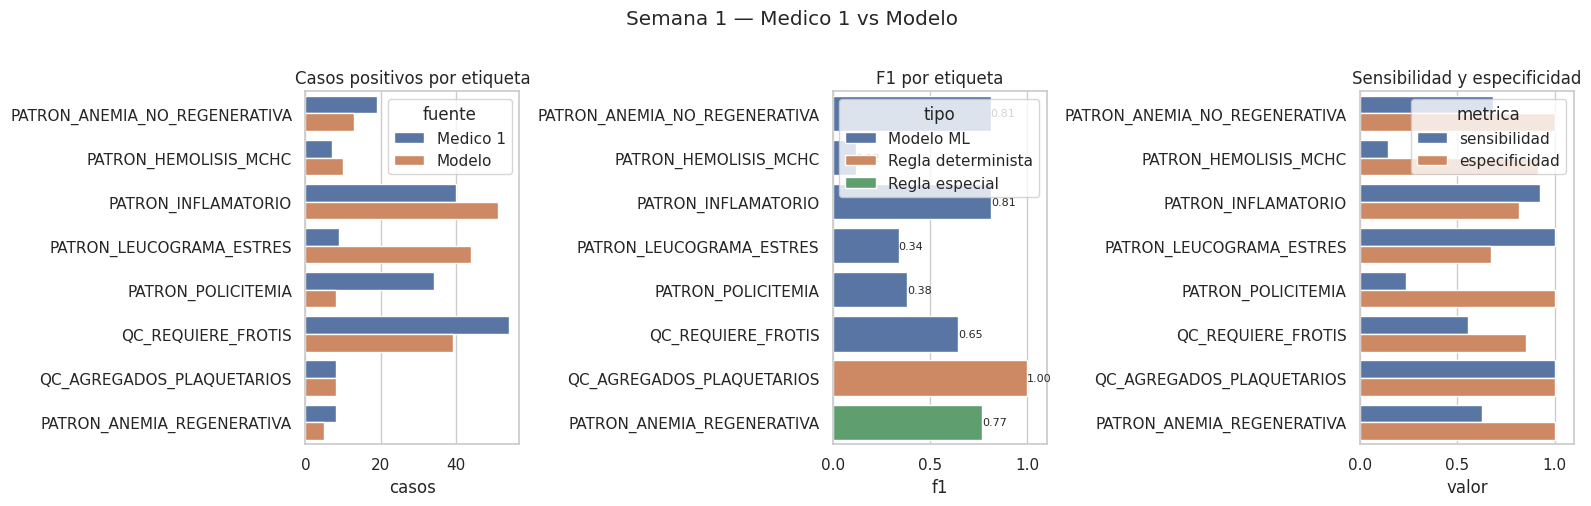

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

pos_largo = metricas_s1.melt(
    id_vars='etiqueta', value_vars=['positivos_clinica', 'positivos_modelo'],
    var_name='fuente', value_name='casos'
)
pos_largo['fuente'] = pos_largo['fuente'].replace(
    {'positivos_clinica': 'Medico 1', 'positivos_modelo': 'Modelo'}
)
sns.barplot(data=pos_largo, y='etiqueta', x='casos', hue='fuente', ax=axes[0])
axes[0].set_title('Casos positivos por etiqueta')
axes[0].set_ylabel('')

sns.barplot(data=metricas_s1, y='etiqueta', x='f1', hue='tipo', dodge=False, ax=axes[1])
axes[1].set_title('F1 por etiqueta')
axes[1].set_xlim(0, 1.1)
axes[1].set_ylabel('')
for c in axes[1].containers:
    axes[1].bar_label(c, fmt='%.2f', fontsize=8)

met_largo = metricas_s1.melt(
    id_vars='etiqueta', value_vars=['sensibilidad', 'especificidad'],
    var_name='metrica', value_name='valor'
)
sns.barplot(data=met_largo, y='etiqueta', x='valor', hue='metrica', ax=axes[2])
axes[2].set_title('Sensibilidad y especificidad')
axes[2].set_xlim(0, 1.1)
axes[2].set_ylabel('')

plt.suptitle('Semana 1 — Medico 1 vs Modelo', y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / 'metricas_s1.png', dpi=150, bbox_inches='tight')
plt.show()

### Desacuerdos y mapa de concordancia

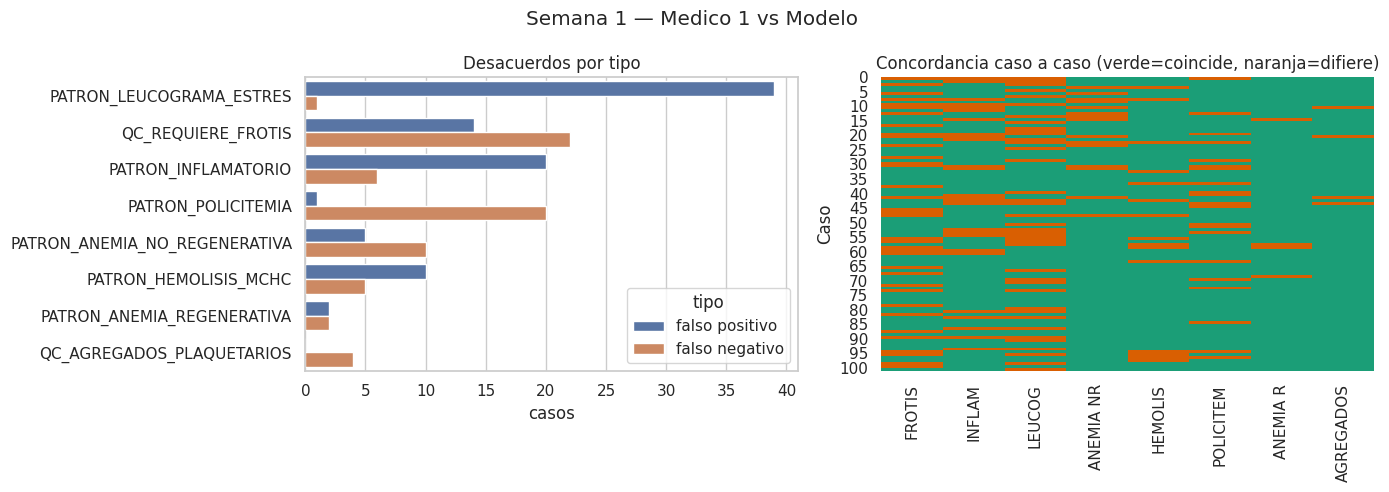

,etiqueta,coinciden,difieren,falso positivo,falso negativo
2,PATRON_LEUCOGRAMA_ESTRES,61,40,39,1
0,QC_REQUIERE_FROTIS,65,36,14,22
1,PATRON_INFLAMATORIO,75,26,20,6
5,PATRON_POLICITEMIA,80,21,1,20
3,PATRON_ANEMIA_NO_REGENERATIVA,86,15,5,10
4,PATRON_HEMOLISIS_MCHC,86,15,10,5
6,PATRON_ANEMIA_REGENERATIVA,97,4,2,2
7,QC_AGREGADOS_PLAQUETARIOS,97,4,0,4


In [9]:
def calcular_desacuerdos(comp, titulo):
    filas = []
    for e in ETIQUETAS:
        clinica = comp[f'respuesta_clinica_{e}'].astype(int)
        modelo  = comp[f'respuesta_modelo_{e}'].astype(int)
        filas.append({
            'etiqueta': e,
            'coinciden': int((clinica == modelo).sum()),
            'difieren':  int((clinica != modelo).sum()),
            'falso positivo': int(((clinica == 0) & (modelo == 1)).sum()),
            'falso negativo':  int(((clinica == 1) & (modelo == 0)).sum()),
        })
    df = pd.DataFrame(filas).sort_values('difieren', ascending=False)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    largo = df.melt(id_vars='etiqueta',
                    value_vars=['falso positivo', 'falso negativo'],
                    var_name='tipo', value_name='casos')
    sns.barplot(data=largo, y='etiqueta', x='casos', hue='tipo', ax=axes[0])
    axes[0].set_title('Desacuerdos por tipo')
    axes[0].set_ylabel('')

    matriz = pd.DataFrame()
    for e in ETIQUETAS:
        matriz[ETIQ_CORTAS[e]] = (
            comp[f'respuesta_clinica_{e}'].astype(int)
            == comp[f'respuesta_modelo_{e}'].astype(int)
        ).astype(int).values
    sns.heatmap(matriz, cmap=['#D95F02', '#1B9E77'], cbar=False, ax=axes[1])
    axes[1].set_title('Concordancia caso a caso (verde=coincide, naranja=difiere)')
    axes[1].set_xlabel('')
    axes[1].set_ylabel('Caso')

    plt.suptitle(titulo)
    plt.tight_layout()
    return df, fig

desc_s1, fig_s1 = calcular_desacuerdos(comp_s1, 'Semana 1 — Medico 1 vs Modelo')
fig_s1.savefig(FIG_DIR / 'desacuerdos_s1.png', dpi=150, bbox_inches='tight')
plt.show()
display(desc_s1)

## Semana 2 — 2 al 7 de junio de 2026

> **Qué se hizo:** Segunda ronda de revisión con 12 batches nuevos (nunca vistos por el modelo ni los médicos antes). Los hemogramas fueron seleccionados del mismo archivo original para evitar sesgos. Se mantiene el modelo v3 para poder comparar el rendimiento de forma consistente a lo largo de las semanas.

In [10]:
manifest_s2[['batch', 'casos_detectados', 'fecha_revision_sugerida']].rename(
    columns={'batch': 'Batch', 'casos_detectados': 'Casos caninos', 'fecha_revision_sugerida': 'Fecha'}
)

,Batch,Casos caninos,Fecha
0,batch_13,7,2026-06-02
1,batch_14,9,2026-06-02
2,batch_15,9,2026-06-02
3,batch_16,9,2026-06-03
4,batch_17,10,2026-06-03
5,batch_18,10,2026-06-03
6,batch_19,8,2026-06-04
7,batch_20,9,2026-06-04
8,batch_21,8,2026-06-04
9,batch_22,10,2026-06-05


### Anotaciones del Médico 1 por batch

In [11]:
mostrar_batches(medico1_s2)

**Batch 13** (7 casos)

,FROTIS,INFLAM,LEUCOG,ANEMIA NR,HEMOLIS,POLICITEM,ANEMIA R,AGREGADOS
#,,,,,,,,
1,,,,x,,,,
2,,x,x,,x,,,
3,x,,,,,,x,
4,x,,,,,,x,
5,x,x,,,,,,
6,,,x,,,,,x
7,,,,,,x,,


**Batch 14** (9 casos)

,FROTIS,INFLAM,LEUCOG,ANEMIA NR,HEMOLIS,POLICITEM,ANEMIA R,AGREGADOS
#,,,,,,,,
1,,,,,,,,
2,,,,,,,,
3,,,,,,x,,
4,x,,x,,x,,,
5,,,,,x,x,,
6,,,,,,x,,
7,x,,x,,,,,
8,,x,,,x,,,
9,x,x,,,x,,,


**Batch 15** (9 casos)

...

,FROTIS,INFLAM,LEUCOG,ANEMIA NR,HEMOLIS,POLICITEM,ANEMIA R,AGREGADOS
#,,,,,,,,
1,,,,,,,,
2,,x,,,,x,,
3,x,,x,,,,,
4,,x,x,,,,,
5,,,,,,,,
6,,,x,,,,,
7,x,,x,x,,,,
8,,x,x,,,,,
9,x,x,x,,,,,


**Batch 23** (10 casos)

,FROTIS,INFLAM,LEUCOG,ANEMIA NR,HEMOLIS,POLICITEM,ANEMIA R,AGREGADOS
#,,,,,,,,
1,,x,x,,,,,
2,,x,,,x,,x,
3,x,x,,,,,,
4,,x,x,,,,,
5,x,,,,,,,
6,x,,x,,,,,
7,,,,,,,x,
8,x,,x,,,,,
9,x,x,,,,,,


**Batch 24** (1 casos)

,FROTIS,INFLAM,LEUCOG,ANEMIA NR,HEMOLIS,POLICITEM,ANEMIA R,AGREGADOS
#,,,,,,,,
1,,,,,,,,


### Anotaciones del Médico 2 por batch

In [12]:
mostrar_batches(medico2_s2, col_prefijo='respuesta_medico2')

**Batch 13** (7 casos)

,FROTIS,INFLAM,LEUCOG,ANEMIA NR,HEMOLIS,POLICITEM,ANEMIA R,AGREGADOS
#,,,,,,,,
1,,,,x,,,,
2,,x,x,,,,,
3,x,,,,x,,,
4,x,,,,,,x,
5,x,,,,x,,,
6,,,x,,x,,,x
7,,,,,,x,,


**Batch 14** (9 casos)

,FROTIS,INFLAM,LEUCOG,ANEMIA NR,HEMOLIS,POLICITEM,ANEMIA R,AGREGADOS
#,,,,,,,,
1,,,x,,,,,
2,,x,,,,,,
3,x,,,,x,,,
4,x,,x,,x,,,
5,,,,,x,x,,
6,,x,,,,,,
7,x,,x,,,,,
8,,x,,,x,x,,
9,x,x,,,x,,,


**Batch 15** (9 casos)

...

,FROTIS,INFLAM,LEUCOG,ANEMIA NR,HEMOLIS,POLICITEM,ANEMIA R,AGREGADOS
#,,,,,,,,
1,,,,,,x,,
2,,x,,,,x,,
3,x,,x,,,,,
4,,x,x,,,,,
5,,,,,x,,,
6,,,x,,,x,,
7,x,,x,x,x,,,
8,,x,x,x,,,x,
9,x,x,x,,,,,


**Batch 23** (10 casos)

,FROTIS,INFLAM,LEUCOG,ANEMIA NR,HEMOLIS,POLICITEM,ANEMIA R,AGREGADOS
#,,,,,,,,
1,,x,,,,,,
2,,x,,,,,x,
3,x,x,x,,,,,
4,,x,,,,x,,
5,x,,,x,,,,
6,x,,,,,x,,
7,,,,,,,x,
8,,,x,,,,,
9,x,x,,,,,,


**Batch 24** (1 casos)

,FROTIS,INFLAM,LEUCOG,ANEMIA NR,HEMOLIS,POLICITEM,ANEMIA R,AGREGADOS
#,,,,,,,,
1,,,,,,,,


In [13]:
def calcular_metricas(comp):
    filas = []
    for e in ETIQUETAS:
        y_clin = comp[f'respuesta_clinica_{e}'].astype(int)
        y_mod  = comp[f'respuesta_modelo_{e}'].astype(int)
        tp = int(((y_clin == 1) & (y_mod == 1)).sum())
        tn = int(((y_clin == 0) & (y_mod == 0)).sum())
        fp = int(((y_clin == 0) & (y_mod == 1)).sum())
        fn = int(((y_clin == 1) & (y_mod == 0)).sum())
        prec = tp / (tp + fp) if (tp + fp) > 0 else 0
        sens = tp / (tp + fn) if (tp + fn) > 0 else 0
        spec = tn / (tn + fp) if (tn + fp) > 0 else 0
        f1   = 2 * prec * sens / (prec + sens) if (prec + sens) > 0 else 0
        filas.append({
            'tipo': TIPOS[e], 'etiqueta': e,
            'positivos medico1': int(y_clin.sum()),
            'positivos modelo':  int(y_mod.sum()),
            'precision': round(prec, 4), 'sensibilidad': round(sens, 4),
            'especificidad': round(spec, 4), 'f1': round(f1, 4),
        })
    return pd.DataFrame(filas).sort_values(['tipo', 'etiqueta'])

metricas_s2 = calcular_metricas(comp_s2)
metricas_s2

,tipo,etiqueta,positivos medico1,positivos modelo,precision,sensibilidad,especificidad,f1
3,Modelo ML,PATRON_ANEMIA_NO_REGENERATIVA,15,10,1.0000,0.6667,1.0000,0.8000
4,Modelo ML,PATRON_HEMOLISIS_MCHC,12,9,0.7778,0.5833,0.9773,0.6667
1,Modelo ML,PATRON_INFLAMATORIO,44,46,0.8913,0.9318,0.9107,0.9111
2,Modelo ML,PATRON_LEUCOGRAMA_ESTRES,42,53,0.7170,0.9048,0.7414,0.8000
5,Modelo ML,PATRON_POLICITEMIA,13,5,0.8000,0.3077,0.9885,0.4444
0,Modelo ML,QC_REQUIERE_FROTIS,37,44,0.7727,0.9189,0.8413,0.8395
7,Regla determinista,QC_AGREGADOS_PLAQUETARIOS,6,5,1.0000,0.8333,1.0000,0.9091
6,Regla especial,PATRON_ANEMIA_REGENERATIVA,8,8,0.7500,0.7500,0.9783,0.7500


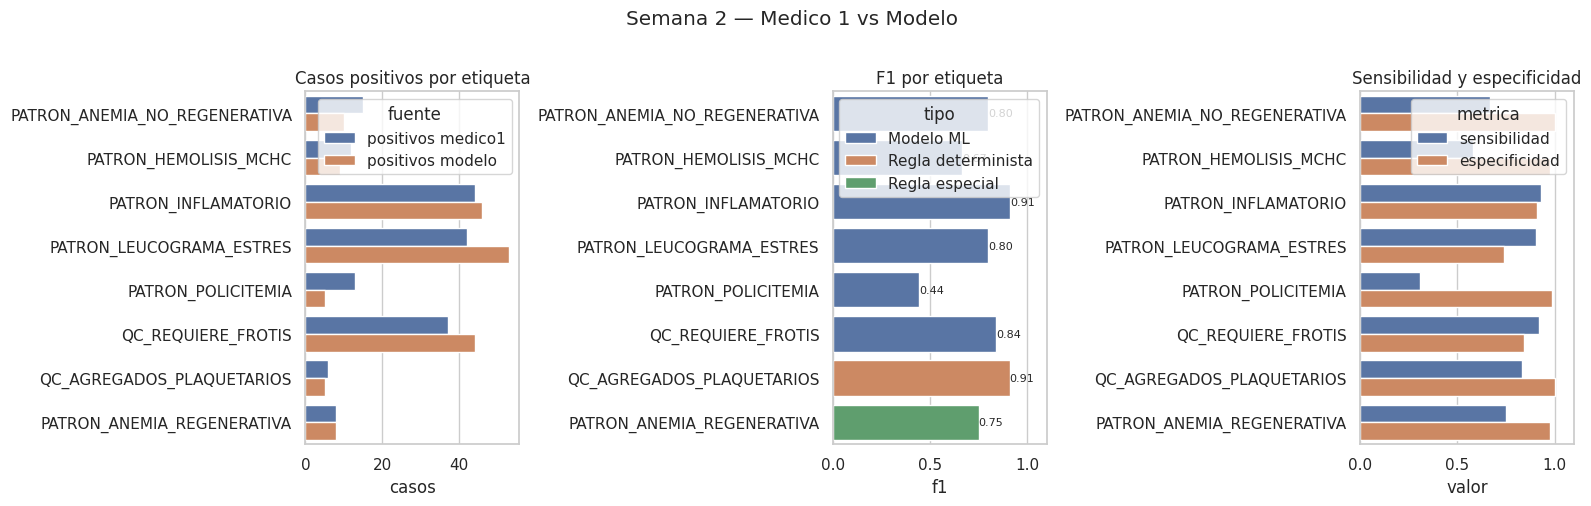

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

pos2 = metricas_s2.melt(
    id_vars='etiqueta', value_vars=['positivos medico1', 'positivos modelo'],
    var_name='fuente', value_name='casos'
)
sns.barplot(data=pos2, y='etiqueta', x='casos', hue='fuente', ax=axes[0])
axes[0].set_title('Casos positivos por etiqueta')
axes[0].set_ylabel('')

sns.barplot(data=metricas_s2, y='etiqueta', x='f1', hue='tipo', dodge=False, ax=axes[1])
axes[1].set_title('F1 por etiqueta')
axes[1].set_xlim(0, 1.1)
axes[1].set_ylabel('')
for c in axes[1].containers:
    axes[1].bar_label(c, fmt='%.2f', fontsize=8)

met2 = metricas_s2.melt(
    id_vars='etiqueta', value_vars=['sensibilidad', 'especificidad'],
    var_name='metrica', value_name='valor'
)
sns.barplot(data=met2, y='etiqueta', x='valor', hue='metrica', ax=axes[2])
axes[2].set_title('Sensibilidad y especificidad')
axes[2].set_xlim(0, 1.1)
axes[2].set_ylabel('')

plt.suptitle('Semana 2 — Medico 1 vs Modelo', y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / 'metricas_s2.png', dpi=150, bbox_inches='tight')
plt.show()

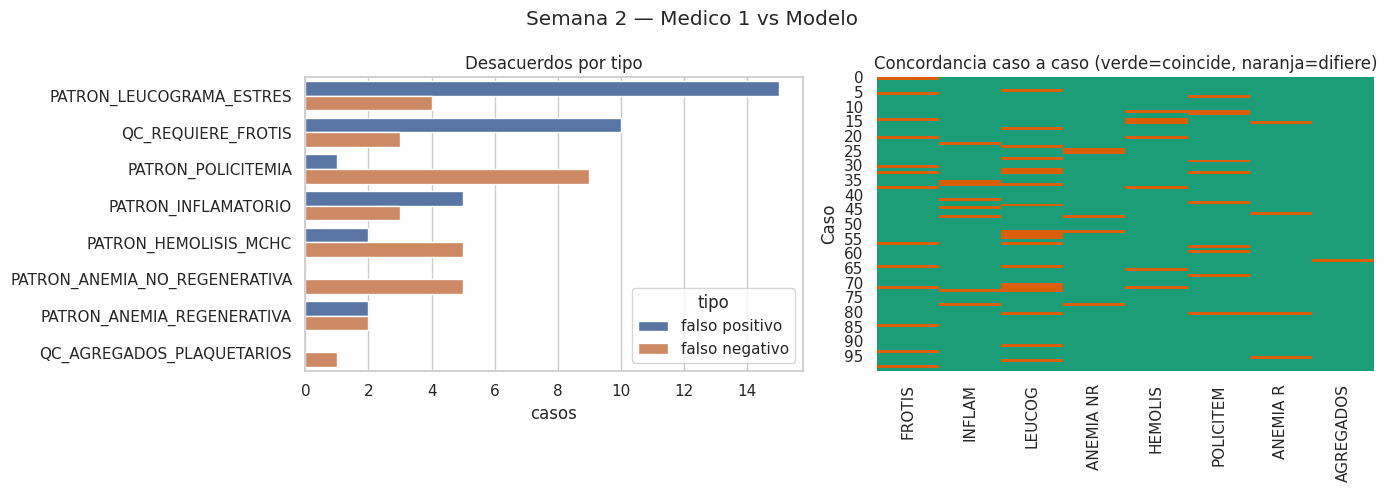

,etiqueta,coinciden,difieren,falso positivo,falso negativo
2,PATRON_LEUCOGRAMA_ESTRES,81,19,15,4
0,QC_REQUIERE_FROTIS,87,13,10,3
5,PATRON_POLICITEMIA,90,10,1,9
1,PATRON_INFLAMATORIO,92,8,5,3
4,PATRON_HEMOLISIS_MCHC,93,7,2,5
3,PATRON_ANEMIA_NO_REGENERATIVA,95,5,0,5
6,PATRON_ANEMIA_REGENERATIVA,96,4,2,2
7,QC_AGREGADOS_PLAQUETARIOS,99,1,0,1


In [15]:
desc_s2, fig_s2 = calcular_desacuerdos(comp_s2, 'Semana 2 — Medico 1 vs Modelo')
fig_s2.savefig(FIG_DIR / 'desacuerdos_s2.png', dpi=150, bbox_inches='tight')
plt.show()
display(desc_s2)

## Semana 3 — 9 al 13 de junio de 2026

> **Qué se hizo:** Tercera ronda con 12 batches adicionales, usando aún el modelo v3. Al finalizar esta semana se tiene suficiente evidencia para identificar qué patrones el modelo predice con bajo acuerdo respecto a los médicos. Esas etiquetas problemáticas motivaron el reentrenamiento del modelo (Notebook 10).

In [16]:
manifest_s3[['batch', 'casos_detectados', 'fecha_revision_sugerida']].rename(
    columns={'batch': 'Batch', 'casos_detectados': 'Casos caninos', 'fecha_revision_sugerida': 'Fecha'}
)

,Batch,Casos caninos,Fecha
0,batch_25,10,2026-06-09
1,batch_26,10,2026-06-09
2,batch_27,10,2026-06-09
3,batch_28,7,2026-06-10
4,batch_29,9,2026-06-10
5,batch_30,10,2026-06-10
6,batch_31,8,2026-06-11
7,batch_32,10,2026-06-11
8,batch_33,6,2026-06-11
9,batch_34,7,2026-06-12


In [17]:
mostrar_batches(medico1_s3)

**Batch 25** (10 casos)

,FROTIS,INFLAM,LEUCOG,ANEMIA NR,HEMOLIS,POLICITEM,ANEMIA R,AGREGADOS
#,,,,,,,,
1,x,x,,,x,,,
2,,x,,,,,,
3,,,,,x,,,x
4,x,x,,,,x,,
5,,x,x,,,,,
6,,x,x,x,,,,
7,x,x,,,x,,,
8,,,,,,,,
9,x,x,x,x,,,,


**Batch 26** (10 casos)

,FROTIS,INFLAM,LEUCOG,ANEMIA NR,HEMOLIS,POLICITEM,ANEMIA R,AGREGADOS
#,,,,,,,,
1,,,,,,,,
2,x,x,,,x,,,
3,,x,x,,,,,x
4,,,,,,,,
5,,,,,,,,
6,x,x,,,,,,
7,x,,,,,,,
8,,,,,,,,
9,,x,,,,,,


**Batch 27** (10 casos)

...

,FROTIS,INFLAM,LEUCOG,ANEMIA NR,HEMOLIS,POLICITEM,ANEMIA R,AGREGADOS
#,,,,,,,,
2,,,,,,,,
3,x,x,x,x,x,,,
5,,x,x,,,,,
6,,,,,,,,x
7,x,,,,,,,
8,,x,x,x,,,,
9,x,,x,,,,,x


**Batch 35** (8 casos)

,FROTIS,INFLAM,LEUCOG,ANEMIA NR,HEMOLIS,POLICITEM,ANEMIA R,AGREGADOS
#,,,,,,,,
1,x,,,,,,,
2,,x,,,,,,
3,x,,,,,,,
4,,x,x,,,,,
5,,x,x,,,,,
6,x,x,x,x,,,,
7,,,x,,,,,
8,,x,,x,x,,,


**Batch 36** (10 casos)

,FROTIS,INFLAM,LEUCOG,ANEMIA NR,HEMOLIS,POLICITEM,ANEMIA R,AGREGADOS
#,,,,,,,,
1,x,,,x,,,,
2,,,,,,,,
3,x,x,x,,,,,
4,,,x,x,,,,
5,,,,,,,,
6,x,x,,,,,,
7,,,,,,,,
8,x,,,x,x,,,
9,x,x,x,,,x,x,


### Anotaciones del Médico 2 por batch

In [18]:
mostrar_batches(medico2_s3, col_prefijo='respuesta_medico2')

**Batch 25** (10 casos)

,FROTIS,INFLAM,LEUCOG,ANEMIA NR,HEMOLIS,POLICITEM,ANEMIA R,AGREGADOS
#,,,,,,,,
1,x,x,,,x,,,
2,,x,x,,,,x,
3,,,,,x,,,x
4,x,x,,x,,x,,
5,,x,x,,,,,
6,,x,x,x,x,,,
7,x,x,,,x,,,
8,,x,,,,,,
9,x,x,x,,,x,,


**Batch 26** (10 casos)

,FROTIS,INFLAM,LEUCOG,ANEMIA NR,HEMOLIS,POLICITEM,ANEMIA R,AGREGADOS
#,,,,,,,,
1,,,,,,,,
2,x,x,,,,,,x
3,,x,x,,,x,,x
4,,,,,,,,
5,,,x,,,x,x,
6,x,x,,,,,,
7,x,,,,x,,,
8,x,,,,x,,,
9,,x,,x,,x,,


**Batch 27** (10 casos)

...

,FROTIS,INFLAM,LEUCOG,ANEMIA NR,HEMOLIS,POLICITEM,ANEMIA R,AGREGADOS
#,,,,,,,,
2,,,,,,,,
3,x,x,x,x,x,,,
5,,x,x,x,x,,,
6,,,,,,,,x
7,x,,,,x,,,
8,,x,x,,,,,
9,x,x,x,,,,,x


**Batch 35** (8 casos)

,FROTIS,INFLAM,LEUCOG,ANEMIA NR,HEMOLIS,POLICITEM,ANEMIA R,AGREGADOS
#,,,,,,,,
1,x,,,,,,,
2,,x,x,,,,,
3,x,,x,,,,,
4,,x,,,,,,
5,,x,x,,,,,
6,x,x,,x,,,x,x
7,,,,x,,x,,
8,,x,,x,x,,x,


**Batch 36** (10 casos)

,FROTIS,INFLAM,LEUCOG,ANEMIA NR,HEMOLIS,POLICITEM,ANEMIA R,AGREGADOS
#,,,,,,,,
1,x,,,x,,,,
2,x,,,,x,,,
3,x,x,x,,x,,x,x
4,,x,x,x,,,,
5,,,,,,,,
6,x,x,,,,,,
7,,,,,,,x,
8,x,,,x,,,,
9,x,x,x,,,x,x,


In [19]:
metricas_s3 = calcular_metricas(comp_s3)
metricas_s3

,tipo,etiqueta,positivos medico1,positivos modelo,precision,sensibilidad,especificidad,f1
3,Modelo ML,PATRON_ANEMIA_NO_REGENERATIVA,18,12,0.8333,0.5556,0.9770,0.6667
4,Modelo ML,PATRON_HEMOLISIS_MCHC,14,16,0.6250,0.7143,0.9341,0.6667
1,Modelo ML,PATRON_INFLAMATORIO,46,48,0.8750,0.9130,0.8983,0.8936
2,Modelo ML,PATRON_LEUCOGRAMA_ESTRES,40,46,0.7609,0.8750,0.8308,0.8140
5,Modelo ML,PATRON_POLICITEMIA,10,5,1.0000,0.5000,1.0000,0.6667
0,Modelo ML,QC_REQUIERE_FROTIS,35,31,0.9355,0.8286,0.9714,0.8788
7,Regla determinista,QC_AGREGADOS_PLAQUETARIOS,11,10,1.0000,0.9091,1.0000,0.9524
6,Regla especial,PATRON_ANEMIA_REGENERATIVA,7,5,0.6000,0.4286,0.9796,0.5000


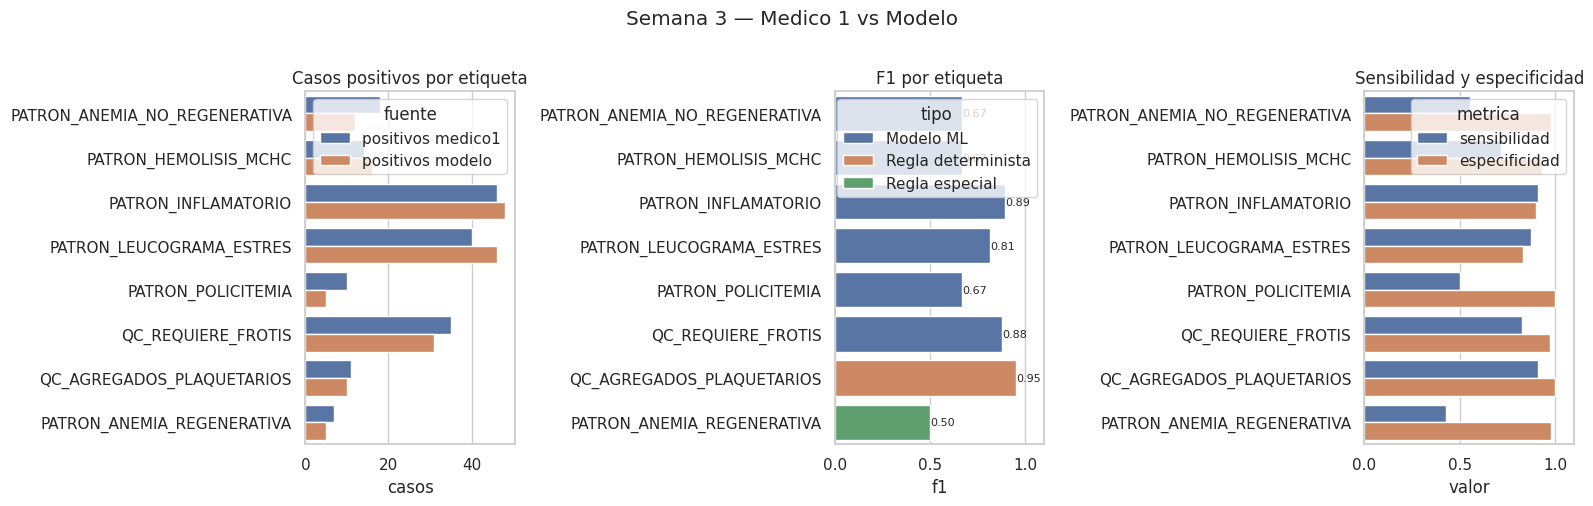

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

pos3 = metricas_s3.melt(
    id_vars='etiqueta', value_vars=['positivos medico1', 'positivos modelo'],
    var_name='fuente', value_name='casos'
)
sns.barplot(data=pos3, y='etiqueta', x='casos', hue='fuente', ax=axes[0])
axes[0].set_title('Casos positivos por etiqueta')
axes[0].set_ylabel('')

sns.barplot(data=metricas_s3, y='etiqueta', x='f1', hue='tipo', dodge=False, ax=axes[1])
axes[1].set_title('F1 por etiqueta')
axes[1].set_xlim(0, 1.1)
axes[1].set_ylabel('')
for c in axes[1].containers:
    axes[1].bar_label(c, fmt='%.2f', fontsize=8)

met3 = metricas_s3.melt(
    id_vars='etiqueta', value_vars=['sensibilidad', 'especificidad'],
    var_name='metrica', value_name='valor'
)
sns.barplot(data=met3, y='etiqueta', x='valor', hue='metrica', ax=axes[2])
axes[2].set_title('Sensibilidad y especificidad')
axes[2].set_xlim(0, 1.1)
axes[2].set_ylabel('')

plt.suptitle('Semana 3 — Medico 1 vs Modelo', y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / 'metricas_s3.png', dpi=150, bbox_inches='tight')
plt.show()

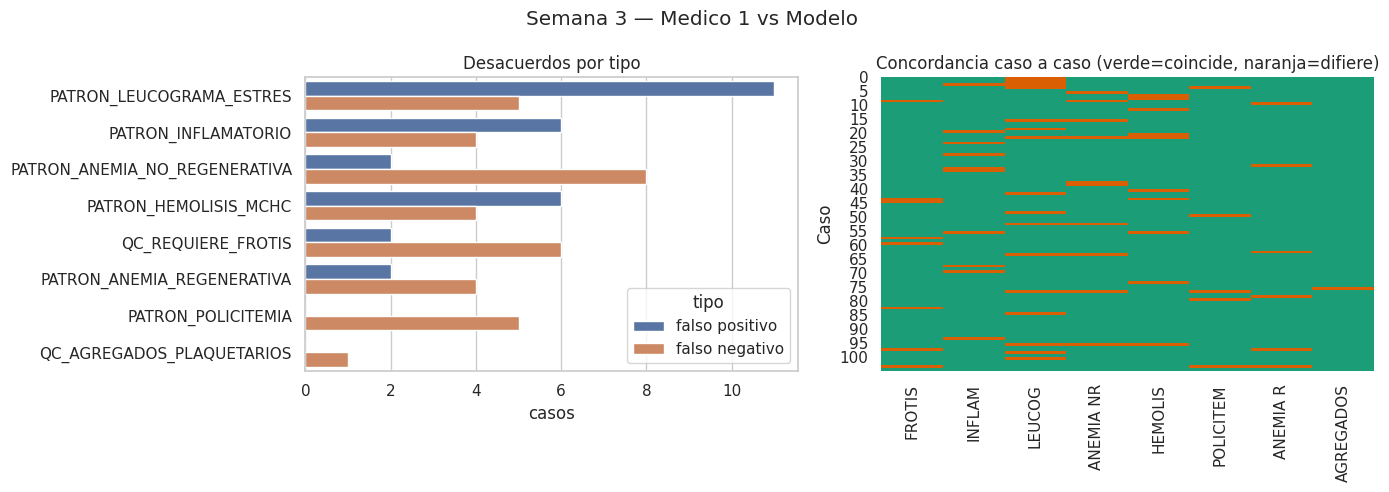

,etiqueta,coinciden,difieren,falso positivo,falso negativo
2,PATRON_LEUCOGRAMA_ESTRES,89,16,11,5
1,PATRON_INFLAMATORIO,95,10,6,4
3,PATRON_ANEMIA_NO_REGENERATIVA,95,10,2,8
4,PATRON_HEMOLISIS_MCHC,95,10,6,4
0,QC_REQUIERE_FROTIS,97,8,2,6
6,PATRON_ANEMIA_REGENERATIVA,99,6,2,4
5,PATRON_POLICITEMIA,100,5,0,5
7,QC_AGREGADOS_PLAQUETARIOS,104,1,0,1


In [21]:
desc_s3, fig_s3 = calcular_desacuerdos(comp_s3, 'Semana 3 — Medico 1 vs Modelo')
fig_s3.savefig(FIG_DIR / 'desacuerdos_s3.png', dpi=150, bbox_inches='tight')
plt.show()
display(desc_s3)

## Semana 4 — 14 al 18 de junio de 2026

> **Qué se hizo:** La cuarta semana evaluó el modelo **v4** (reentrenado con datos adicionales de MYTHIC_VET). Se procesaron 24 batches para tener suficiente poder estadístico. El objetivo es verificar si el reentrenamiento mejoró el acuerdo modelo-médico en las etiquetas que habían resultado problemáticas.

In [22]:
manifest_s3b[['batch', 'casos_detectados', 'fecha_revision_sugerida']].rename(
    columns={'batch': 'Batch', 'casos_detectados': 'Casos caninos', 'fecha_revision_sugerida': 'Fecha'}
)

,Batch,Casos caninos,Fecha
0,batch_37,8,2026-06-14
1,batch_38,10,2026-06-14
2,batch_39,10,2026-06-14
3,batch_40,8,2026-06-14
4,batch_41,10,2026-06-14
5,batch_42,10,2026-06-14
6,batch_43,10,2026-06-15
7,batch_44,9,2026-06-15
8,batch_45,9,2026-06-15
9,batch_46,10,2026-06-15


### Anotaciones del Médico 1 por batch

In [23]:
mostrar_batches(medico1_s3b)

**Batch 37** (8 casos)

,FROTIS,INFLAM,LEUCOG,ANEMIA NR,HEMOLIS,POLICITEM,ANEMIA R,AGREGADOS
#,,,,,,,,
1,,x,,,x,,,
2,,,x,,x,,,
3,,,,,,,,
4,x,,,x,x,x,,
5,x,,x,,,,,
6,,,,x,,,,
7,,,,,x,,,
8,x,x,x,,x,,,


**Batch 38** (10 casos)

,FROTIS,INFLAM,LEUCOG,ANEMIA NR,HEMOLIS,POLICITEM,ANEMIA R,AGREGADOS
#,,,,,,,,
1,x,,x,x,x,,,
2,,x,x,,,x,x,
3,x,,x,x,,,,
4,x,x,,,x,,,
5,,,x,,,,,
6,x,x,,,,,,
7,x,,,,,,,
8,x,,,,,,,
9,x,,,,,,,


**Batch 39** (10 casos)

...

,FROTIS,INFLAM,LEUCOG,ANEMIA NR,HEMOLIS,POLICITEM,ANEMIA R,AGREGADOS
#,,,,,,,,
1,,,,,,,,
2,,,,,,,,
3,x,,,x,,,,
4,x,x,x,x,,,,
5,,,,,,,,
6,,,,,x,,,
7,x,x,x,,,x,,
8,,x,x,x,,,,


**Batch 59** (8 casos)

,FROTIS,INFLAM,LEUCOG,ANEMIA NR,HEMOLIS,POLICITEM,ANEMIA R,AGREGADOS
#,,,,,,,,
1,,x,,,,,,
2,,,,,,,,
3,,,,,,x,,
4,,,,,,x,,
5,x,,,,x,,x,
6,x,,,,,x,,x
7,,x,,,,,,
8,x,,x,,,x,,x


**Batch 60** (7 casos)

,FROTIS,INFLAM,LEUCOG,ANEMIA NR,HEMOLIS,POLICITEM,ANEMIA R,AGREGADOS
#,,,,,,,,
1,,x,x,x,,,,
2,,,,,,,,
3,x,,x,x,,,,
4,,,,,,,,
5,,x,,,,,,
6,,x,x,x,,,,
7,,,,,,,,


### Anotaciones del Médico 2 por batch

In [24]:
mostrar_batches(medico2_s3b, col_prefijo='respuesta_medico2')

**Batch 37** (8 casos)

,FROTIS,INFLAM,LEUCOG,ANEMIA NR,HEMOLIS,POLICITEM,ANEMIA R,AGREGADOS
#,,,,,,,,
1,,x,,,x,,,
2,,,,,x,,x,
3,,,,,,,,
4,x,,,,x,x,,
5,x,,x,,,,,
6,,,,x,x,,,
7,,,,,x,,,
8,x,,x,,x,,,


**Batch 38** (10 casos)

,FROTIS,INFLAM,LEUCOG,ANEMIA NR,HEMOLIS,POLICITEM,ANEMIA R,AGREGADOS
#,,,,,,,,
1,x,,x,,x,x,,
2,,x,x,,,x,x,
3,x,,x,x,,,,
4,x,x,,,,,,x
5,,,x,,,x,,
6,x,x,,,,,,
7,x,,x,,,x,x,
8,x,,,,,,,
9,x,,,,x,,,


**Batch 39** (10 casos)

...

,FROTIS,INFLAM,LEUCOG,ANEMIA NR,HEMOLIS,POLICITEM,ANEMIA R,AGREGADOS
#,,,,,,,,
1,,x,,x,,,,
2,,,,,,,,
3,x,,,x,,,x,
4,x,x,x,x,,,,
5,,,,,,,x,
6,,,,,x,,x,
7,x,x,x,,,x,,
8,,x,x,x,,,x,x


**Batch 59** (8 casos)

,FROTIS,INFLAM,LEUCOG,ANEMIA NR,HEMOLIS,POLICITEM,ANEMIA R,AGREGADOS
#,,,,,,,,
1,,x,,,,,,
2,,x,,,,,,
3,,,,,x,x,,
4,,,,,x,x,,
5,x,,x,,x,x,x,
6,x,,,,x,x,,x
7,,x,,,,,,x
8,x,,x,,x,x,,x


**Batch 60** (7 casos)

,FROTIS,INFLAM,LEUCOG,ANEMIA NR,HEMOLIS,POLICITEM,ANEMIA R,AGREGADOS
#,,,,,,,,
1,,x,x,x,x,,,
2,,,,x,,,,
3,x,,,x,,,,
4,,,,x,,,,
5,,x,,,,x,,
6,,x,x,x,x,,,
7,x,,,,,,,


In [25]:
metricas_s3b = calcular_metricas(comp_s3b)
metricas_s3b

,tipo,etiqueta,positivos medico1,positivos modelo,precision,sensibilidad,especificidad,f1
3,Modelo ML,PATRON_ANEMIA_NO_REGENERATIVA,34,23,0.8261,0.5588,0.9763,0.6667
4,Modelo ML,PATRON_HEMOLISIS_MCHC,31,27,0.7407,0.6452,0.9593,0.6897
1,Modelo ML,PATRON_INFLAMATORIO,79,79,0.9114,0.9114,0.9435,0.9114
2,Modelo ML,PATRON_LEUCOGRAMA_ESTRES,68,82,0.6463,0.7794,0.7852,0.7067
5,Modelo ML,PATRON_POLICITEMIA,28,25,0.7600,0.6786,0.9657,0.7170
0,Modelo ML,QC_REQUIERE_FROTIS,79,74,0.8649,0.8101,0.9194,0.8366
7,Regla determinista,QC_AGREGADOS_PLAQUETARIOS,12,10,0.9000,0.7500,0.9948,0.8182
6,Regla especial,PATRON_ANEMIA_REGENERATIVA,15,6,1.0000,0.4000,1.0000,0.5714


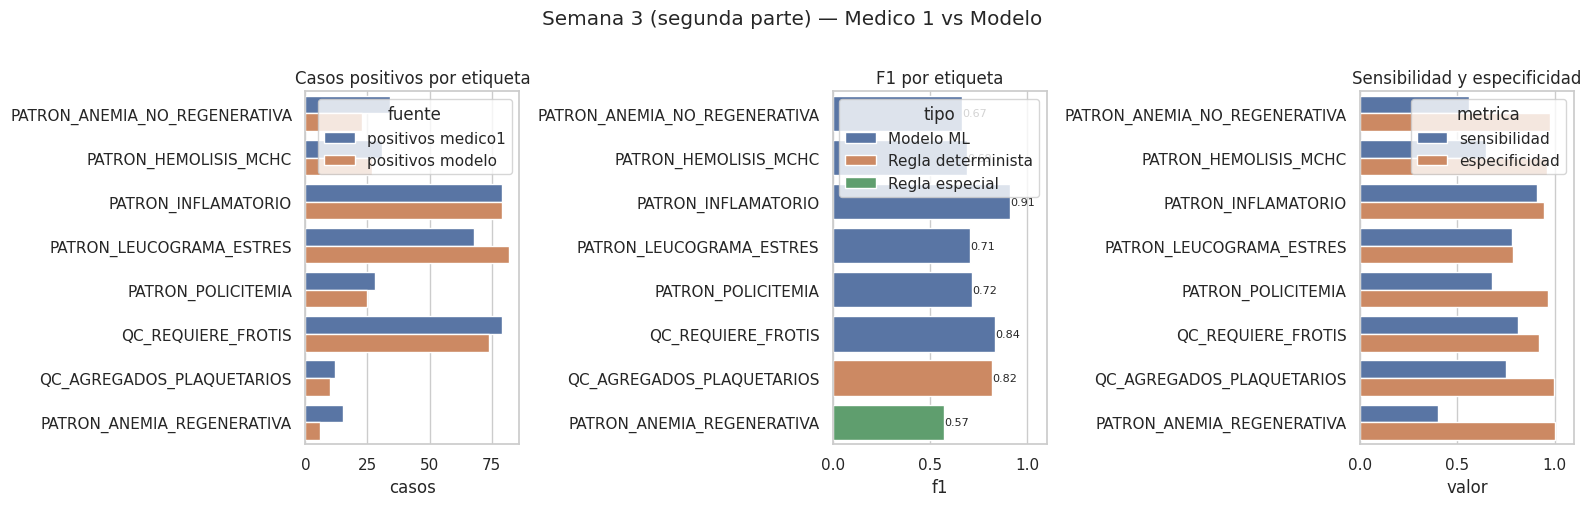

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

pos3b = metricas_s3b.melt(
    id_vars='etiqueta', value_vars=['positivos medico1', 'positivos modelo'],
    var_name='fuente', value_name='casos'
)
sns.barplot(data=pos3b, y='etiqueta', x='casos', hue='fuente', ax=axes[0])
axes[0].set_title('Casos positivos por etiqueta')
axes[0].set_ylabel('')

sns.barplot(data=metricas_s3b, y='etiqueta', x='f1', hue='tipo', dodge=False, ax=axes[1])
axes[1].set_title('F1 por etiqueta')
axes[1].set_xlim(0, 1.1)
axes[1].set_ylabel('')
for c in axes[1].containers:
    axes[1].bar_label(c, fmt='%.2f', fontsize=8)

met3b = metricas_s3b.melt(
    id_vars='etiqueta', value_vars=['sensibilidad', 'especificidad'],
    var_name='metrica', value_name='valor'
)
sns.barplot(data=met3b, y='etiqueta', x='valor', hue='metrica', ax=axes[2])
axes[2].set_title('Sensibilidad y especificidad')
axes[2].set_xlim(0, 1.1)
axes[2].set_ylabel('')

plt.suptitle('Semana 3 (segunda parte) — Medico 1 vs Modelo', y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / 'metricas_s3b.png', dpi=150, bbox_inches='tight')
plt.show()

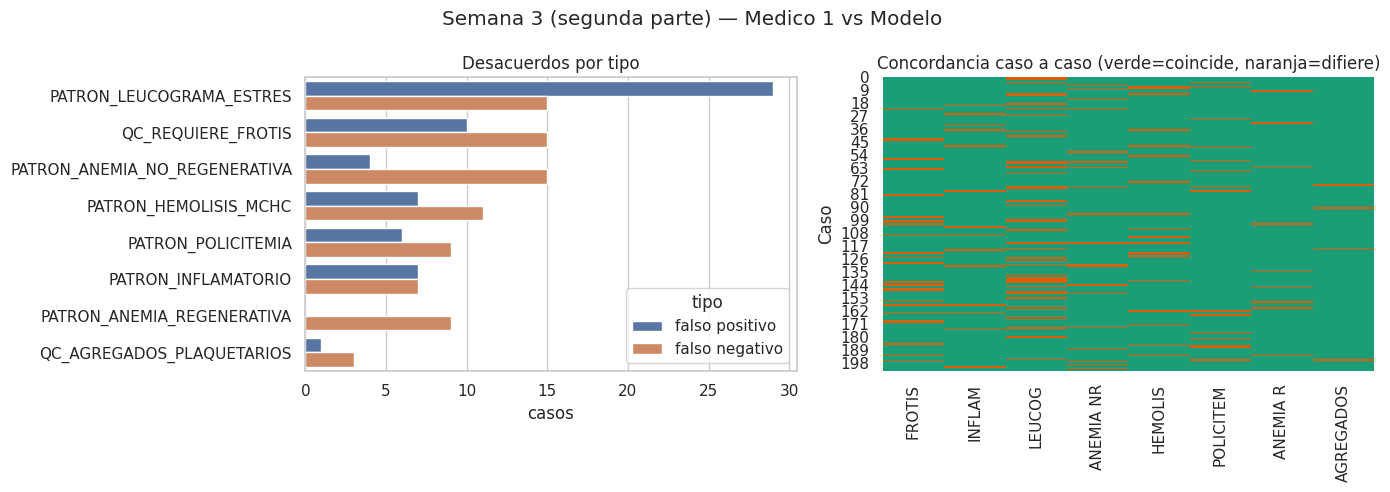

,etiqueta,coinciden,difieren,falso positivo,falso negativo
2,PATRON_LEUCOGRAMA_ESTRES,159,44,29,15
0,QC_REQUIERE_FROTIS,178,25,10,15
3,PATRON_ANEMIA_NO_REGENERATIVA,184,19,4,15
4,PATRON_HEMOLISIS_MCHC,185,18,7,11
5,PATRON_POLICITEMIA,188,15,6,9
1,PATRON_INFLAMATORIO,189,14,7,7
6,PATRON_ANEMIA_REGENERATIVA,194,9,0,9
7,QC_AGREGADOS_PLAQUETARIOS,199,4,1,3


In [27]:
desc_s3b, fig_s3b = calcular_desacuerdos(comp_s3b, 'Semana 3 (segunda parte) — Medico 1 vs Modelo')
fig_s3b.savefig(FIG_DIR / 'desacuerdos_s3b.png', dpi=150, bbox_inches='tight')
plt.show()
display(desc_s3b)

## Concordancia entre evaluadores — Índice de Cohen

> **Para el lector no especialista:** Aquí medimos si los dos médicos y el modelo "ven lo mismo" en el mismo hemograma. El índice Kappa (κ) cuantifica esto más rigurosamente que el simple porcentaje de acuerdo, porque descuenta las coincidencias que ocurrirían por azar.

| κ | Interpretación | ¿Es aceptable? |
|---|---------------|----------------|
| < 0.20 | Leve | ✗ Inaceptable |
| 0.20–0.39 | Regular | ✗ Insuficiente |
| 0.40–0.59 | Moderado | ⚠ Marginal |
| 0.60–0.79 | Sustancial | ✓ Aceptable |
| ≥ 0.80 | Casi perfecto | ✓✓ Excelente |

**Comparaciones que se calculan:**
1. **M1 vs M2** → mide el acuerdo *entre médicos* (referencia del nivel de dificultad del problema)
2. **M1 vs Modelo** → mide si el sistema acuerda con el médico principal
3. **M2 vs Modelo** → confirma que el patrón se repite con el segundo evaluador

In [28]:
def nivel_kappa(k):
    if k < 0.20: return 'Leve'
    if k < 0.40: return 'Regular'
    if k < 0.60: return 'Moderado'
    if k < 0.80: return 'Sustancial'
    return 'Casi perfecto'

def tabla_kappa(comp, col_a, col_b, label_a, label_b):
    filas = []
    for e in ETIQUETAS:
        try:
            k = cohen_kappa_score(
                comp[f'{col_a}_{e}'].astype(int),
                comp[f'{col_b}_{e}'].astype(int),
            )
        except Exception:
            k = float('nan')
        filas.append({
            'tipo': TIPOS[e], 'etiqueta': e,
            'kappa': round(k, 3),
            'nivel': nivel_kappa(k) if not np.isnan(k) else 'N/A',
        })
    df = pd.DataFrame(filas)
    display(Markdown(f"**{label_a} vs {label_b}**"))
    display(df)
    return df

kappa_s1_m1m2  = tabla_kappa(comp_s1, 'respuesta_clinica', 'respuesta_medico2', 'Medico 1', 'Medico 2 — semana 1')
kappa_s1_m1mod = tabla_kappa(comp_s1, 'respuesta_clinica', 'respuesta_modelo',  'Medico 1', 'Modelo — semana 1')

**Medico 1 vs Medico 2 — semana 1**

,tipo,etiqueta,kappa,nivel
0,Modelo ML,QC_REQUIERE_FROTIS,0.782,Sustancial
1,Modelo ML,PATRON_INFLAMATORIO,0.850,Casi perfecto
2,Modelo ML,PATRON_LEUCOGRAMA_ESTRES,0.313,Regular
3,Modelo ML,PATRON_ANEMIA_NO_REGENERATIVA,0.778,Sustancial
4,Modelo ML,PATRON_HEMOLISIS_MCHC,0.500,Moderado
5,Modelo ML,PATRON_POLICITEMIA,0.839,Casi perfecto
6,Regla especial,PATRON_ANEMIA_REGENERATIVA,0.489,Moderado
7,Regla determinista,QC_AGREGADOS_PLAQUETARIOS,0.918,Casi perfecto


**Medico 1 vs Modelo — semana 1**

,tipo,etiqueta,kappa,nivel
0,Modelo ML,QC_REQUIERE_FROTIS,0.276,Regular
1,Modelo ML,PATRON_INFLAMATORIO,0.477,Moderado
2,Modelo ML,PATRON_LEUCOGRAMA_ESTRES,0.126,Leve
3,Modelo ML,PATRON_ANEMIA_NO_REGENERATIVA,0.399,Regular
4,Modelo ML,PATRON_HEMOLISIS_MCHC,-0.071,Leve
5,Modelo ML,PATRON_POLICITEMIA,0.369,Regular
6,Regla especial,PATRON_ANEMIA_REGENERATIVA,0.579,Moderado
7,Regla determinista,QC_AGREGADOS_PLAQUETARIOS,0.485,Moderado


In [29]:
kappa_s2_m1m2   = tabla_kappa(comp_s2,  'respuesta_clinica', 'respuesta_medico2', 'Medico 1', 'Medico 2 — semana 2')
kappa_s2_m1mod  = tabla_kappa(comp_s2,  'respuesta_clinica', 'respuesta_modelo',  'Medico 1', 'Modelo — semana 2')
kappa_s3_m1m2   = tabla_kappa(comp_s3,  'respuesta_clinica', 'respuesta_medico2', 'Medico 1', 'Medico 2 — semana 3')
kappa_s3_m1mod  = tabla_kappa(comp_s3,  'respuesta_clinica', 'respuesta_modelo',  'Medico 1', 'Modelo — semana 3')
kappa_s3b_m1m2  = tabla_kappa(comp_s3b, 'respuesta_clinica', 'respuesta_medico2', 'Medico 1', 'Medico 2 — semana 3b')
kappa_s3b_m1mod = tabla_kappa(comp_s3b, 'respuesta_clinica', 'respuesta_modelo',  'Medico 1', 'Modelo — semana 3b')

**Medico 1 vs Medico 2 — semana 2**

,tipo,etiqueta,kappa,nivel
0,Modelo ML,QC_REQUIERE_FROTIS,0.892,Casi perfecto
1,Modelo ML,PATRON_INFLAMATORIO,0.878,Casi perfecto
2,Modelo ML,PATRON_LEUCOGRAMA_ESTRES,0.795,Sustancial
3,Modelo ML,PATRON_ANEMIA_NO_REGENERATIVA,0.692,Sustancial
4,Modelo ML,PATRON_HEMOLISIS_MCHC,0.464,Moderado
5,Modelo ML,PATRON_POLICITEMIA,0.439,Moderado
6,Regla especial,PATRON_ANEMIA_REGENERATIVA,0.630,Sustancial
7,Regla determinista,QC_AGREGADOS_PLAQUETARIOS,0.918,Casi perfecto


**Medico 1 vs Modelo — semana 2**

,tipo,etiqueta,kappa,nivel
0,Modelo ML,QC_REQUIERE_FROTIS,0.732,Sustancial
1,Modelo ML,PATRON_INFLAMATORIO,0.838,Casi perfecto
2,Modelo ML,PATRON_LEUCOGRAMA_ESTRES,0.624,Sustancial
3,Modelo ML,PATRON_ANEMIA_NO_REGENERATIVA,0.773,Sustancial
4,Modelo ML,PATRON_HEMOLISIS_MCHC,0.628,Sustancial
5,Modelo ML,PATRON_POLICITEMIA,0.401,Moderado
6,Regla especial,PATRON_ANEMIA_REGENERATIVA,0.728,Sustancial
7,Regla determinista,QC_AGREGADOS_PLAQUETARIOS,0.904,Casi perfecto


**Medico 1 vs Medico 2 — semana 3**

...

,tipo,etiqueta,kappa,nivel
0,Modelo ML,QC_REQUIERE_FROTIS,0.824,Casi perfecto
1,Modelo ML,PATRON_INFLAMATORIO,0.807,Casi perfecto
2,Modelo ML,PATRON_LEUCOGRAMA_ESTRES,0.686,Sustancial
3,Modelo ML,PATRON_ANEMIA_NO_REGENERATIVA,0.614,Sustancial
4,Modelo ML,PATRON_HEMOLISIS_MCHC,0.611,Sustancial
5,Modelo ML,PATRON_POLICITEMIA,0.644,Sustancial
6,Regla especial,PATRON_ANEMIA_REGENERATIVA,0.471,Moderado
7,Regla determinista,QC_AGREGADOS_PLAQUETARIOS,0.947,Casi perfecto


**Medico 1 vs Medico 2 — semana 3b**

,tipo,etiqueta,kappa,nivel
0,Modelo ML,QC_REQUIERE_FROTIS,0.896,Casi perfecto
1,Modelo ML,PATRON_INFLAMATORIO,0.848,Casi perfecto
2,Modelo ML,PATRON_LEUCOGRAMA_ESTRES,0.701,Sustancial
3,Modelo ML,PATRON_ANEMIA_NO_REGENERATIVA,0.639,Sustancial
4,Modelo ML,PATRON_HEMOLISIS_MCHC,0.518,Moderado
5,Modelo ML,PATRON_POLICITEMIA,0.674,Sustancial
6,Regla especial,PATRON_ANEMIA_REGENERATIVA,0.502,Moderado
7,Regla determinista,QC_AGREGADOS_PLAQUETARIOS,0.597,Moderado


**Medico 1 vs Modelo — semana 3b**

,tipo,etiqueta,kappa,nivel
0,Modelo ML,QC_REQUIERE_FROTIS,0.738,Sustancial
1,Modelo ML,PATRON_INFLAMATORIO,0.855,Casi perfecto
2,Modelo ML,PATRON_LEUCOGRAMA_ESTRES,0.537,Moderado
3,Modelo ML,PATRON_ANEMIA_NO_REGENERATIVA,0.615,Sustancial
4,Modelo ML,PATRON_HEMOLISIS_MCHC,0.638,Sustancial
5,Modelo ML,PATRON_POLICITEMIA,0.675,Sustancial
6,Regla especial,PATRON_ANEMIA_REGENERATIVA,0.553,Moderado
7,Regla determinista,QC_AGREGADOS_PLAQUETARIOS,0.808,Casi perfecto


In [30]:
# Kappa M2 vs Modelo — perspectiva del segundo evaluador
kappa_s1_m2mod  = tabla_kappa(comp_s1,  'respuesta_medico2', 'respuesta_modelo', 'Medico 2', 'Modelo — semana 1')
kappa_s2_m2mod  = tabla_kappa(comp_s2,  'respuesta_medico2', 'respuesta_modelo', 'Medico 2', 'Modelo — semana 2')
kappa_s3_m2mod  = tabla_kappa(comp_s3,  'respuesta_medico2', 'respuesta_modelo', 'Medico 2', 'Modelo — semana 3')
kappa_s3b_m2mod = tabla_kappa(comp_s3b, 'respuesta_medico2', 'respuesta_modelo', 'Medico 2', 'Modelo — semana 4')

**Medico 2 vs Modelo — semana 1**

,tipo,etiqueta,kappa,nivel
0,Modelo ML,QC_REQUIERE_FROTIS,0.067,Leve
1,Modelo ML,PATRON_INFLAMATORIO,0.499,Moderado
2,Modelo ML,PATRON_LEUCOGRAMA_ESTRES,0.055,Leve
3,Modelo ML,PATRON_ANEMIA_NO_REGENERATIVA,0.235,Regular
4,Modelo ML,PATRON_HEMOLISIS_MCHC,-0.110,Leve
5,Modelo ML,PATRON_POLICITEMIA,0.302,Regular
6,Regla especial,PATRON_ANEMIA_REGENERATIVA,0.262,Regular
7,Regla determinista,QC_AGREGADOS_PLAQUETARIOS,0.427,Moderado


**Medico 2 vs Modelo — semana 2**

,tipo,etiqueta,kappa,nivel
0,Modelo ML,QC_REQUIERE_FROTIS,0.627,Sustancial
1,Modelo ML,PATRON_INFLAMATORIO,0.717,Sustancial
2,Modelo ML,PATRON_LEUCOGRAMA_ESTRES,0.505,Moderado
3,Modelo ML,PATRON_ANEMIA_NO_REGENERATIVA,0.500,Moderado
4,Modelo ML,PATRON_HEMOLISIS_MCHC,0.161,Leve
5,Modelo ML,PATRON_POLICITEMIA,0.163,Leve
6,Regla especial,PATRON_ANEMIA_REGENERATIVA,0.419,Moderado
7,Regla determinista,QC_AGREGADOS_PLAQUETARIOS,0.823,Casi perfecto


**Medico 2 vs Modelo — semana 3**

,tipo,etiqueta,kappa,nivel
0,Modelo ML,QC_REQUIERE_FROTIS,0.716,Sustancial
1,Modelo ML,PATRON_INFLAMATORIO,0.637,Sustancial
2,Modelo ML,PATRON_LEUCOGRAMA_ESTRES,0.435,Moderado
3,Modelo ML,PATRON_ANEMIA_NO_REGENERATIVA,0.329,Regular
4,Modelo ML,PATRON_HEMOLISIS_MCHC,0.191,Leve
5,Modelo ML,PATRON_POLICITEMIA,0.369,Regular
6,Regla especial,PATRON_ANEMIA_REGENERATIVA,0.215,Regular
7,Regla determinista,QC_AGREGADOS_PLAQUETARIOS,0.674,Sustancial


**Medico 2 vs Modelo — semana 4**

,tipo,etiqueta,kappa,nivel
0,Modelo ML,QC_REQUIERE_FROTIS,0.633,Sustancial
1,Modelo ML,PATRON_INFLAMATORIO,0.768,Sustancial
2,Modelo ML,PATRON_LEUCOGRAMA_ESTRES,0.361,Regular
3,Modelo ML,PATRON_ANEMIA_NO_REGENERATIVA,0.375,Regular
4,Modelo ML,PATRON_HEMOLISIS_MCHC,0.274,Regular
5,Modelo ML,PATRON_POLICITEMIA,0.413,Moderado
6,Regla especial,PATRON_ANEMIA_REGENERATIVA,0.227,Regular
7,Regla determinista,QC_AGREGADOS_PLAQUETARIOS,0.447,Moderado


### Interpretación de la concordancia M2 vs Modelo

Si el modelo concuerda bien con M1 pero mal con M2 (o viceversa), podría indicar un sesgo de uno de los evaluadores. Si el modelo concuerda mal con **ambos** en la misma etiqueta, el problema es del modelo.

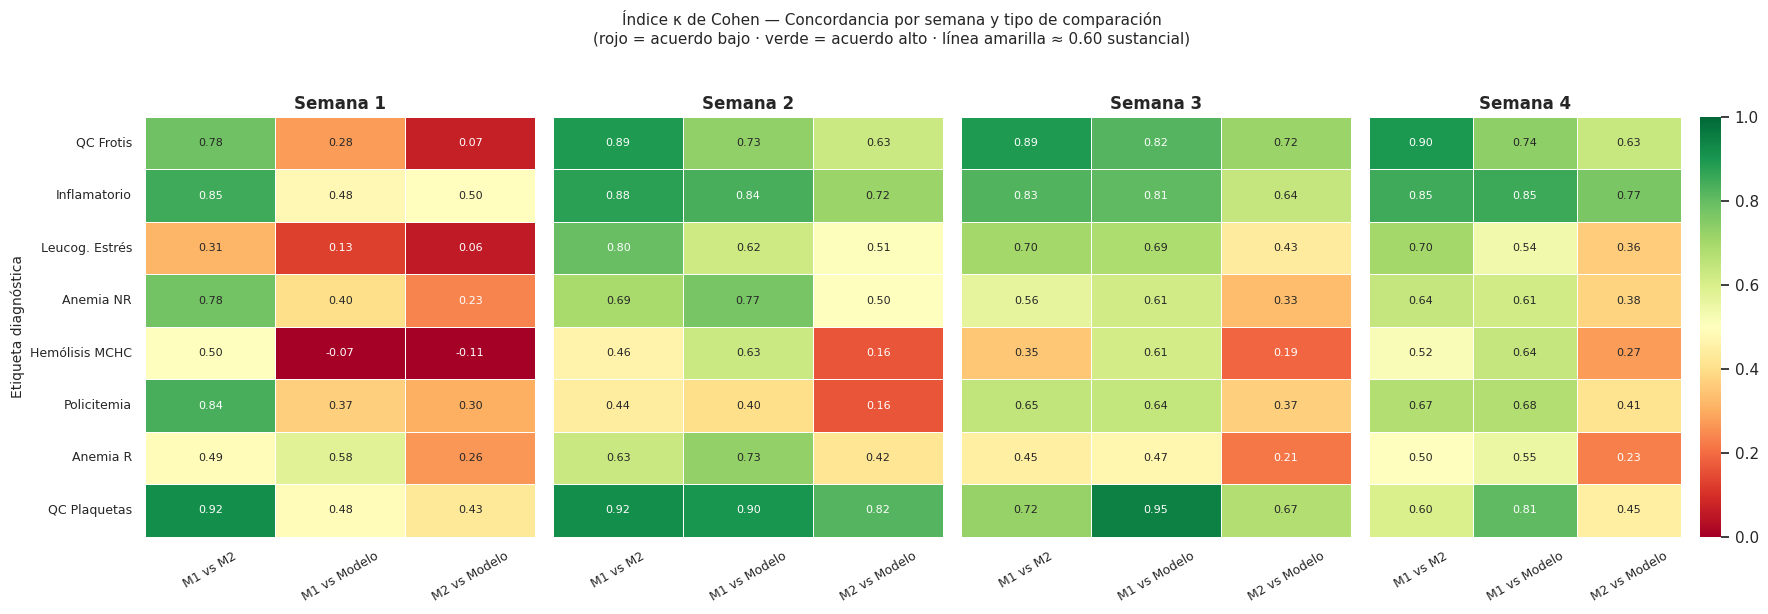

,M1-M2 S1,M1-Mod S1,M2-Mod S1,M1-M2 S2,M1-Mod S2,M2-Mod S2,M1-M2 S3,M1-Mod S3,M2-Mod S3,M1-M2 S4,M1-Mod S4,M2-Mod S4
QC Frotis,0.782,0.276,0.067,0.892,0.732,0.627,0.894,0.824,0.716,0.896,0.738,0.633
Inflamatorio,0.850,0.477,0.499,0.878,0.838,0.717,0.828,0.807,0.637,0.848,0.855,0.768
Leucog. Estrés,0.313,0.126,0.055,0.795,0.624,0.505,0.701,0.686,0.435,0.701,0.537,0.361
Anemia NR,0.778,0.399,0.235,0.692,0.773,0.500,0.564,0.614,0.329,0.639,0.615,0.375
Hemólisis MCHC,0.500,-0.071,-0.110,0.464,0.628,0.161,0.351,0.611,0.191,0.518,0.638,0.274
Policitemia,0.839,0.369,0.302,0.439,0.401,0.163,0.645,0.644,0.369,0.674,0.675,0.413
Anemia R,0.489,0.579,0.262,0.630,0.728,0.419,0.448,0.471,0.215,0.502,0.553,0.227
QC Plaquetas,0.918,0.485,0.427,0.918,0.904,0.823,0.723,0.947,0.674,0.597,0.808,0.447


In [31]:
# ─── Resumen Kappa en formato heatmap ─────────────────────────────────────────
# Un heatmap es más legible que un gráfico de barras con 64 categorías.
# Filas = etiquetas diagnósticas, Columnas = comparación × semana
# Color = valor de kappa (rojo=bajo, verde=alto)

kappa_completo = (
    kappa_s1_m1m2[['etiqueta','kappa']].rename(columns={'kappa':'M1-M2 S1'})
    .merge(kappa_s1_m1mod[['etiqueta','kappa']].rename(columns={'kappa':'M1-Mod S1'}), on='etiqueta')
    .merge(kappa_s1_m2mod[['etiqueta','kappa']].rename(columns={'kappa':'M2-Mod S1'}), on='etiqueta')
    .merge(kappa_s2_m1m2[['etiqueta','kappa']].rename(columns={'kappa':'M1-M2 S2'}),  on='etiqueta')
    .merge(kappa_s2_m1mod[['etiqueta','kappa']].rename(columns={'kappa':'M1-Mod S2'}), on='etiqueta')
    .merge(kappa_s2_m2mod[['etiqueta','kappa']].rename(columns={'kappa':'M2-Mod S2'}), on='etiqueta')
    .merge(kappa_s3_m1m2[['etiqueta','kappa']].rename(columns={'kappa':'M1-M2 S3'}),  on='etiqueta')
    .merge(kappa_s3_m1mod[['etiqueta','kappa']].rename(columns={'kappa':'M1-Mod S3'}), on='etiqueta')
    .merge(kappa_s3_m2mod[['etiqueta','kappa']].rename(columns={'kappa':'M2-Mod S3'}), on='etiqueta')
    .merge(kappa_s3b_m1m2[['etiqueta','kappa']].rename(columns={'kappa':'M1-M2 S4'}), on='etiqueta')
    .merge(kappa_s3b_m1mod[['etiqueta','kappa']].rename(columns={'kappa':'M1-Mod S4'}), on='etiqueta')
    .merge(kappa_s3b_m2mod[['etiqueta','kappa']].rename(columns={'kappa':'M2-Mod S4'}), on='etiqueta')
    .set_index('etiqueta')
)

ETIQ_CORTAS_MAPA = {
    'QC_REQUIERE_FROTIS':            'QC Frotis',
    'PATRON_INFLAMATORIO':           'Inflamatorio',
    'PATRON_LEUCOGRAMA_ESTRES':      'Leucog. Estrés',
    'PATRON_ANEMIA_NO_REGENERATIVA': 'Anemia NR',
    'PATRON_HEMOLISIS_MCHC':         'Hemólisis MCHC',
    'PATRON_POLICITEMIA':            'Policitemia',
    'PATRON_ANEMIA_REGENERATIVA':    'Anemia R',
    'QC_AGREGADOS_PLAQUETARIOS':     'QC Plaquetas',
}
kappa_completo.index = [ETIQ_CORTAS_MAPA.get(e, e) for e in kappa_completo.index]

fig, axes = plt.subplots(1, 4, figsize=(18, 6), sharey=True)
semanas = ['S1', 'S2', 'S3', 'S4']
cols_por_semana = {
    'S1': ['M1-M2 S1', 'M1-Mod S1', 'M2-Mod S1'],
    'S2': ['M1-M2 S2', 'M1-Mod S2', 'M2-Mod S2'],
    'S3': ['M1-M2 S3', 'M1-Mod S3', 'M2-Mod S3'],
    'S4': ['M1-M2 S4', 'M1-Mod S4', 'M2-Mod S4'],
}
for ax, sem in zip(axes, semanas):
    datos = kappa_completo[cols_por_semana[sem]]
    datos.columns = ['M1 vs M2', 'M1 vs Modelo', 'M2 vs Modelo']
    sns.heatmap(
        datos, ax=ax, vmin=0, vmax=1, cmap='RdYlGn', annot=True, fmt='.2f',
        linewidths=0.5, cbar=(sem == 'S4'), annot_kws={'size': 8},
    )
    ax.set_title(f'Semana {sem[-1]}', fontsize=12, fontweight='bold')
    if sem != 'S1':
        ax.set_ylabel('')
    else:
        ax.set_ylabel('Etiqueta diagnóstica', fontsize=10)
    ax.tick_params(axis='y', labelsize=9, rotation=0)
    ax.tick_params(axis='x', labelsize=9, rotation=30)

fig.suptitle('Índice κ de Cohen — Concordancia por semana y tipo de comparación\n'
             '(rojo = acuerdo bajo · verde = acuerdo alto · línea amarilla ≈ 0.60 sustancial)',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'kappa_heatmap_completo.png', dpi=150, bbox_inches='tight')
plt.show()

display(kappa_completo.style.background_gradient(cmap='RdYlGn', vmin=0, vmax=1).format('{:.3f}'))

### ¿Qué nos dice este mapa de calor?

**Hallazgos clave de S1–S3 (modelo v3):**
- Las etiquetas con κ < 0.60 consistentemente en **M1 vs Modelo** y **M2 vs Modelo** identifican dónde el modelo v3 fallaba.
- Si M1 vs M2 también tiene κ bajo, el problema es de ambigüedad clínica inherente a esa condición (no solo del modelo).
- Estas etiquetas de bajo acuerdo con *ambos* médicos motivaron el reentrenamiento con datos adicionales (MYTHIC_VET) → **modelo v4**.

**Columna S4 (modelo v4):** Compara el mismo tipo de análisis pero ya con el modelo reentrenado. Un incremento de κ en las etiquetas problemáticas confirma que el reentrenamiento fue efectivo.

### Kappa modelo — antes y después del reentrenamiento v4

Comparación del acuerdo M1-Modelo (κ) en S1–S3 frente a S4.

### ¿Por qué se reentrenó el modelo?


El gráfico siguiente muestra directamente el impacto: para cada etiqueta, se compara el κ M1 vs Modelo en S1+S2+S3 (v3) contra S4 (v4). Las barras que crecen confirman la mejora.

**M1 vs Modelo**

,tipo,etiqueta,kappa,nivel
0,Modelo ML,QC_REQUIERE_FROTIS,0.605,Sustancial
1,Modelo ML,PATRON_INFLAMATORIO,0.708,Sustancial
2,Modelo ML,PATRON_LEUCOGRAMA_ESTRES,0.497,Moderado
3,Modelo ML,PATRON_ANEMIA_NO_REGENERATIVA,0.588,Moderado
4,Modelo ML,PATRON_HEMOLISIS_MCHC,0.457,Moderado
5,Modelo ML,PATRON_POLICITEMIA,0.448,Moderado
6,Regla especial,PATRON_ANEMIA_REGENERATIVA,0.607,Sustancial
7,Regla determinista,QC_AGREGADOS_PLAQUETARIOS,0.840,Casi perfecto


**M1 vs Modelo**

,tipo,etiqueta,kappa,nivel
0,Modelo ML,QC_REQUIERE_FROTIS,0.738,Sustancial
1,Modelo ML,PATRON_INFLAMATORIO,0.855,Casi perfecto
2,Modelo ML,PATRON_LEUCOGRAMA_ESTRES,0.537,Moderado
3,Modelo ML,PATRON_ANEMIA_NO_REGENERATIVA,0.615,Sustancial
4,Modelo ML,PATRON_HEMOLISIS_MCHC,0.638,Sustancial
5,Modelo ML,PATRON_POLICITEMIA,0.675,Sustancial
6,Regla especial,PATRON_ANEMIA_REGENERATIVA,0.553,Moderado
7,Regla determinista,QC_AGREGADOS_PLAQUETARIOS,0.808,Casi perfecto


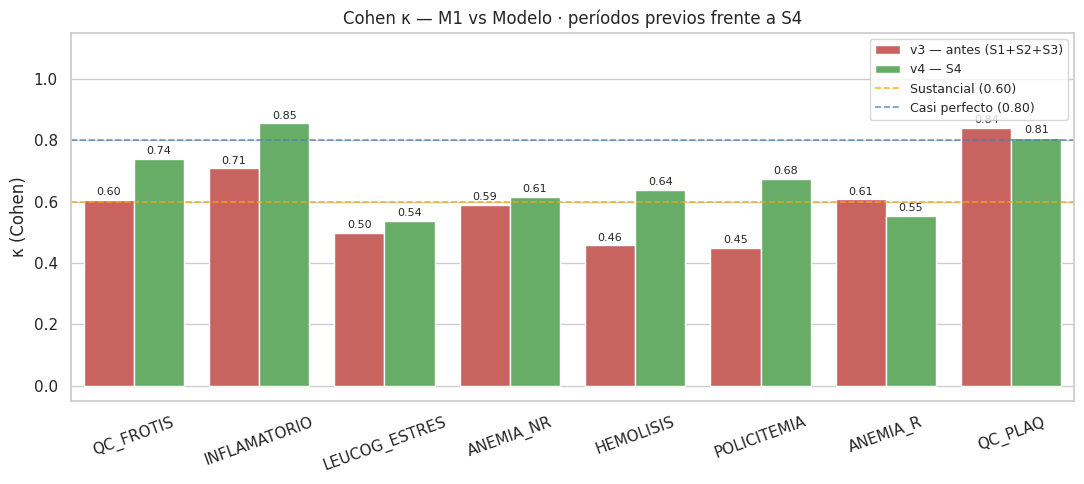

In [32]:
# kappa M1 vs Modelo: períodos S1+S2+S3 combinados frente a S4
comp_pre = pd.concat([
    comp_s1.assign(semana='S1'),
    comp_s2.assign(semana='S2'),
    comp_s3.assign(semana='S3'),
], ignore_index=True)

kappa_pre  = tabla_kappa(comp_pre,  'respuesta_clinica', 'respuesta_modelo', 'M1', 'Modelo')
kappa_post = tabla_kappa(comp_s3b, 'respuesta_clinica', 'respuesta_modelo', 'M1', 'Modelo')

kappa_pre['version']  = 'v3 — antes (S1+S2+S3)'
kappa_post['version'] = 'v4 — S4'

df_plot = pd.concat([kappa_pre[['etiqueta', 'kappa', 'version']],
                     kappa_post[['etiqueta', 'kappa', 'version']]], ignore_index=True)

ETIQ_SHORT = {
    'QC_REQUIERE_FROTIS':            'QC_FROTIS',
    'PATRON_INFLAMATORIO':           'INFLAMATORIO',
    'PATRON_LEUCOGRAMA_ESTRES':      'LEUCOG_ESTRES',
    'PATRON_ANEMIA_NO_REGENERATIVA': 'ANEMIA_NR',
    'PATRON_HEMOLISIS_MCHC':         'HEMOLISIS',
    'PATRON_POLICITEMIA':            'POLICITEMIA',
    'PATRON_ANEMIA_REGENERATIVA':    'ANEMIA_R',
    'QC_AGREGADOS_PLAQUETARIOS':     'QC_PLAQ',
}
df_plot['etiq_short'] = df_plot['etiqueta'].map(ETIQ_SHORT)

palette = {'v3 — antes (S1+S2+S3)': '#d9534f', 'v4 — S4': '#5cb85c'}

fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(data=df_plot, x='etiq_short', y='kappa', hue='version',
            palette=palette, ax=ax)
ax.axhline(y=0.60, color='orange', linestyle='--', linewidth=1.2, alpha=0.8, label='Sustancial (0.60)')
ax.axhline(y=0.80, color='steelblue', linestyle='--', linewidth=1.2, alpha=0.8, label='Casi perfecto (0.80)')
for c in ax.containers:
    ax.bar_label(c, fmt='%.2f', fontsize=8, padding=2)
ax.set_title('Cohen κ — M1 vs Modelo · períodos previos frente a S4', fontsize=12)
ax.set_xlabel('')
ax.set_ylabel('κ (Cohen)')
ax.set_ylim(-0.05, 1.15)
ax.tick_params(axis='x', rotation=20)
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / 'kappa_v3_vs_v4.png', dpi=150, bbox_inches='tight')
plt.show()

## Análisis por etiqueta — Precisión, Recall y F1 (todas las semanas)

Reporte descriptivo por etiqueta sobre los cuatro períodos.

In [33]:
from sklearn.metrics import precision_recall_fscore_support

comp_total = pd.concat([
    comp_s1.assign(semana='S1'),
    comp_s2.assign(semana='S2'),
    comp_s3.assign(semana='S3'),
    comp_s3b.assign(semana='S4'),
], ignore_index=True)

ETIQ_PROBLEMATICAS = {
    'PATRON_HEMOLISIS_MCHC', 'PATRON_POLICITEMIA',
    'PATRON_ANEMIA_NO_REGENERATIVA', 'PATRON_LEUCOGRAMA_ESTRES',
}

filas_metricas = []
for e in ETIQUETAS:
    y_true = comp_total[f'respuesta_clinica_{e}'].astype(int).values
    y_pred = comp_total[f'respuesta_modelo_{e}'].astype(int).values
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='binary', zero_division=0
    )
    fn = int(((y_true == 1) & (y_pred == 0)).sum())
    fp = int(((y_true == 0) & (y_pred == 1)).sum())
    filas_metricas.append({
        'Etiqueta': e,
        'Tipo': TIPOS[e],
        'Soporte (+)': int(y_true.sum()),
        'Precision': round(prec, 3),
        'Recall': round(rec, 3),
        'F1': round(f1, 3),
        'FP': fp,
        'FN': fn,
        'Problematica': '⚠' if e in ETIQ_PROBLEMATICAS else '',
    })

metricas_globales = pd.DataFrame(filas_metricas).sort_values('F1')

def semaforo(val):
    if val >= 0.70: return 'background-color: #d4edda'
    if val >= 0.50: return 'background-color: #fff3cd'
    return 'background-color: #f8d7da'

display(
    metricas_globales.style
    .map(semaforo, subset=['Precision', 'Recall', 'F1'])
    .format({'Precision': '{:.3f}', 'Recall': '{:.3f}', 'F1': '{:.3f}'})
    .set_caption(f"M1 vs Modelo — {len(comp_total)} casos evaluables (S1+S2+S3+S4)")
)

,Etiqueta,Tipo,Soporte (+),Precision,Recall,F1,FP,FN,Problematica
5,PATRON_POLICITEMIA,Modelo ML,80,0.822,0.463,0.592,8,43,⚠
4,PATRON_HEMOLISIS_MCHC,Modelo ML,62,0.597,0.597,0.597,25,25,⚠
6,PATRON_ANEMIA_REGENERATIVA,Regla especial,35,0.750,0.514,0.610,6,17,
3,PATRON_ANEMIA_NO_REGENERATIVA,Modelo ML,84,0.807,0.548,0.652,11,38,⚠
2,PATRON_LEUCOGRAMA_ESTRES,Modelo ML,157,0.584,0.841,0.689,94,25,⚠
0,QC_REQUIERE_FROTIS,Modelo ML,198,0.809,0.768,0.788,36,46,
7,QC_AGREGADOS_PLAQUETARIOS,Regla determinista,35,0.963,0.743,0.839,1,9,
1,PATRON_INFLAMATORIO,Modelo ML,203,0.828,0.901,0.863,38,20,


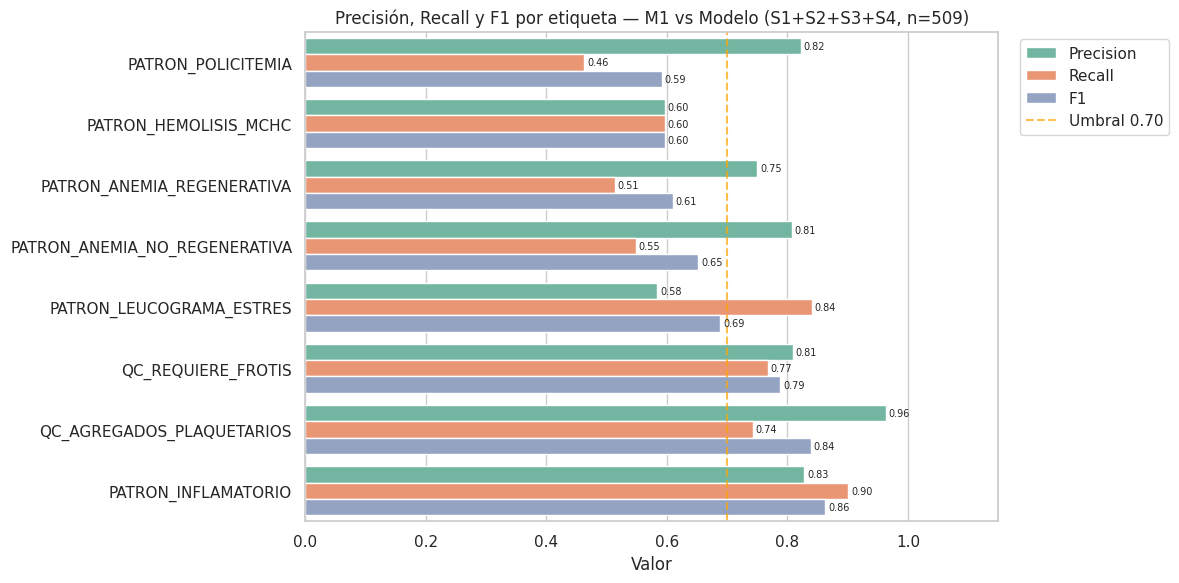

In [34]:
fig, ax = plt.subplots(figsize=(12, 6))
melt = metricas_globales.melt(
    id_vars='Etiqueta', value_vars=['Precision', 'Recall', 'F1'],
    var_name='Métrica', value_name='Valor'
)
sns.barplot(data=melt, y='Etiqueta', x='Valor', hue='Métrica', ax=ax, palette='Set2')
ax.axvline(0.7, color='orange', linestyle='--', alpha=0.7, label='Umbral 0.70')
ax.set_xlim(0, 1.15)
ax.set_title(f'Precisión, Recall y F1 por etiqueta — M1 vs Modelo (S1+S2+S3+S4, n={len(comp_total)})')
ax.set_xlabel('Valor')
ax.set_ylabel('')
for c in ax.containers:
    ax.bar_label(c, fmt='%.2f', fontsize=7, padding=2)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig(FIG_DIR / 'metricas_por_clase_global.png', dpi=150, bbox_inches='tight')
plt.show()

### Perspectiva del Médico 2 — Métricas globales

Para confirmar que los resultados de M1 no son producto de un sesgo individual, se replican las métricas tomando M2 como referencia. Si M1 y M2 producen conclusiones similares, los resultados son más robustos.

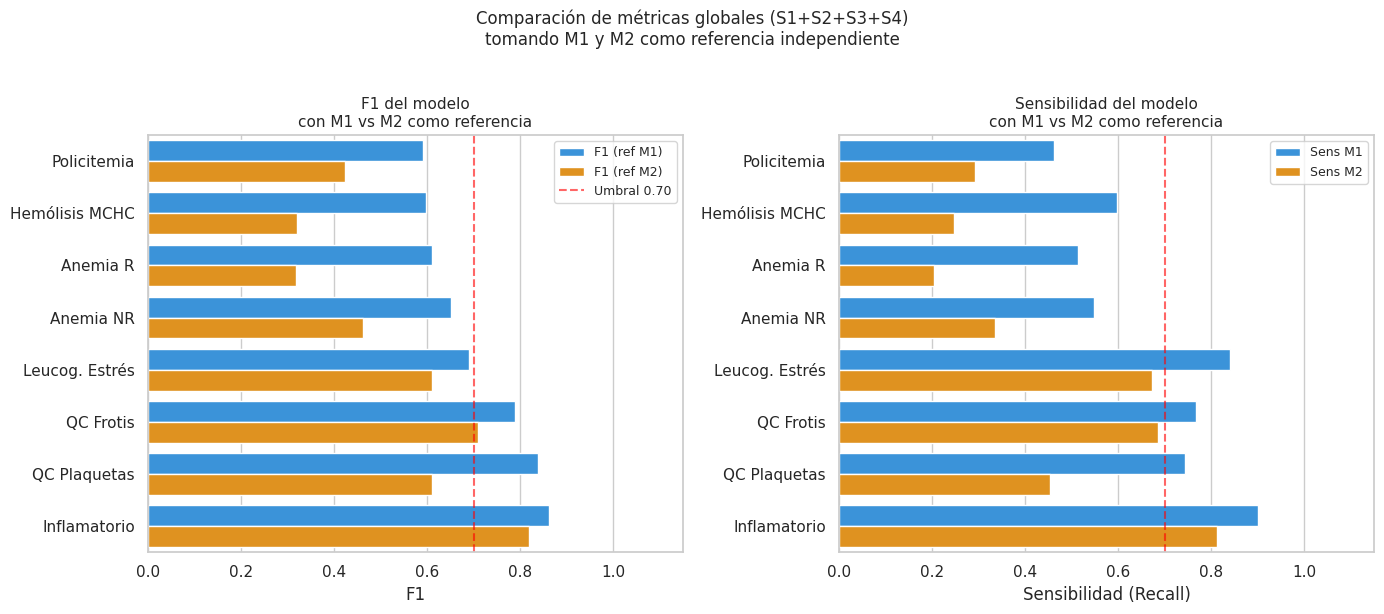

Si M1 y M2 producen conclusiones similares, los resultados son robustos.


In [35]:
def calcular_metricas_m2(comp):
    """Calcula métricas tomando M2 como evaluador de referencia en lugar de M1."""
    filas = []
    for e in ETIQUETAS:
        y_clin = comp[f'respuesta_medico2_{e}'].astype(int)
        y_mod  = comp[f'respuesta_modelo_{e}'].astype(int)
        tp = int(((y_clin == 1) & (y_mod == 1)).sum())
        tn = int(((y_clin == 0) & (y_mod == 0)).sum())
        fp = int(((y_clin == 0) & (y_mod == 1)).sum())
        fn = int(((y_clin == 1) & (y_mod == 0)).sum())
        prec = tp / (tp + fp) if (tp + fp) > 0 else 0
        sens = tp / (tp + fn) if (tp + fn) > 0 else 0
        spec = tn / (tn + fp) if (tn + fp) > 0 else 0
        f1   = 2 * prec * sens / (prec + sens) if (prec + sens) > 0 else 0
        filas.append({
            'tipo': TIPOS[e], 'etiqueta': e,
            'positivos M2': int(y_clin.sum()),
            'positivos modelo': int(y_mod.sum()),
            'precision': round(prec, 4), 'sensibilidad': round(sens, 4),
            'especificidad': round(spec, 4), 'f1': round(f1, 4),
        })
    return pd.DataFrame(filas).sort_values(['tipo', 'etiqueta'])

comp_total_m2 = pd.concat([
    comp_s1.assign(semana='S1'),
    comp_s2.assign(semana='S2'),
    comp_s3.assign(semana='S3'),
    comp_s3b.assign(semana='S4'),
], ignore_index=True)

metricas_m2_global = calcular_metricas_m2(comp_total_m2)

# Comparar M1 vs M2 como referencia
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

metricas_m1_global = metricas_globales.rename(columns={'F1': 'F1 (ref M1)', 'Recall': 'Recall M1', 'Precision': 'Precision M1'})
comp_m1_m2 = metricas_m1_global[['Etiqueta','F1 (ref M1)']].merge(
    metricas_m2_global[['etiqueta','f1']].rename(columns={'etiqueta':'Etiqueta','f1':'F1 (ref M2)'}),
    on='Etiqueta'
)

ETIQ_SHORT_LIST = [ETIQ_CORTAS_MAPA.get(e, e) for e in ETIQUETAS]
etiq_map = dict(zip(ETIQUETAS, ETIQ_SHORT_LIST))
comp_m1_m2['Etiqueta_corta'] = comp_m1_m2['Etiqueta'].map(etiq_map)

largo = comp_m1_m2.melt(id_vars='Etiqueta_corta', value_vars=['F1 (ref M1)', 'F1 (ref M2)'],
                         var_name='Referencia', value_name='F1')
sns.barplot(data=largo, y='Etiqueta_corta', x='F1', hue='Referencia',
            ax=axes[0], palette=['#2196F3','#FF9800'])
axes[0].axvline(0.7, color='red', linestyle='--', alpha=0.6, label='Umbral 0.70')
axes[0].set_title('F1 del modelo\ncon M1 vs M2 como referencia', fontsize=11)
axes[0].set_xlabel('F1')
axes[0].set_ylabel('')
axes[0].set_xlim(0, 1.15)
axes[0].legend(fontsize=9)

# Sensibilidad comparada
comp_sens = metricas_globales[['Etiqueta','Recall']].rename(columns={'Recall':'Sens M1'}).merge(
    metricas_m2_global[['etiqueta','sensibilidad']].rename(columns={'etiqueta':'Etiqueta','sensibilidad':'Sens M2'}),
    on='Etiqueta'
)
comp_sens['Etiqueta_corta'] = comp_sens['Etiqueta'].map(etiq_map)
largo_s = comp_sens.melt(id_vars='Etiqueta_corta', value_vars=['Sens M1','Sens M2'],
                          var_name='Referencia', value_name='Sensibilidad')
sns.barplot(data=largo_s, y='Etiqueta_corta', x='Sensibilidad', hue='Referencia',
            ax=axes[1], palette=['#2196F3','#FF9800'])
axes[1].axvline(0.7, color='red', linestyle='--', alpha=0.6)
axes[1].set_title('Sensibilidad del modelo\ncon M1 vs M2 como referencia', fontsize=11)
axes[1].set_xlabel('Sensibilidad (Recall)')
axes[1].set_ylabel('')
axes[1].set_xlim(0, 1.15)
axes[1].legend(fontsize=9)

plt.suptitle('Comparación de métricas globales (S1+S2+S3+S4)\ntomando M1 y M2 como referencia independiente',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'metricas_m1_vs_m2_referencia.png', dpi=150, bbox_inches='tight')
plt.show()
print("Si M1 y M2 producen conclusiones similares, los resultados son robustos.")

## Resumen

Se procesaron **60 batches** y **526 hemogramas** hasta el jueves 18 de junio de 2026. 509 casos tienen una predicción de modelo evaluable.

| Semana | Período | Batches | Casos (M1 y M2) |
|--------|---------|---------|-----------------|
| Semana 1 | 25–29 mayo 2026 | 12 | 116 |
| Semana 2 | 2–7 junio 2026 | 12 | 100 |
| Semana 3 | 9–13 junio 2026 | 12 | 105 |
| Semana 4 | 14–18 junio 2026 | 24 | 205 |
| **Total completado** | | **60** | **526** |

La evidencia independiente del modelo se reporta en el **Notebook 10**: v4 conserva 18 FN menos que v3, aunque produce 20 FP adicionales y una PR-AUC ligeramente menor. El candidato recalibrado fue rechazado por no cumplir las restricciones de FP/FN.